In [1]:
# =============================================================================
# CELL 1: Download TJNU-GCD from Google Drive
# =============================================================================
!pip install -q gdown

import gdown
import zipfile
import os
import shutil

# Dataset info (from GitHub page)
print("📦 TJNU Ground-based Cloud Dataset (GCD)")
print("   • 19,000 images at 512×512")
print("   • 7 classes (merged similar cloud types)")
print("   • Pre-split: 10,000 train / 9,000 test")
print("   • Annotated by meteorologists")
print()

# Download
GDRIVE_ID = "1dsgoEQLqR3YrOMBC_hOsVEUQC7HuV2fN"
ZIP_FILE = "GCD.zip"
EXTRACT_DIR = "/content/GCD_dataset"

print("⬇️ Downloading (~175MB)...")
gdown.download(f"https://drive.google.com/uc?id={GDRIVE_ID}", ZIP_FILE, quiet=False)

# Extract
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

print("\n📂 Extracting...")
with zipfile.ZipFile(ZIP_FILE, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

# Show structure
print("\n📁 Folder structure:")
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")
        for d in sorted(dirs)[:10]:
            print(f"{indent}  {d}/")

print("\n✅ Ready!")

📦 TJNU Ground-based Cloud Dataset (GCD)
   • 19,000 images at 512×512
   • 7 classes (merged similar cloud types)
   • Pre-split: 10,000 train / 9,000 test
   • Annotated by meteorologists

⬇️ Downloading (~175MB)...


Downloading...
From (original): https://drive.google.com/uc?id=1dsgoEQLqR3YrOMBC_hOsVEUQC7HuV2fN
From (redirected): https://drive.google.com/uc?id=1dsgoEQLqR3YrOMBC_hOsVEUQC7HuV2fN&confirm=t&uuid=0e9826b6-4b5f-4842-868f-093b9093f546
To: /content/GCD.zip
100%|██████████| 184M/184M [00:05<00:00, 36.4MB/s]



📂 Extracting...

📁 Folder structure:
GCD_dataset/
  GCD/
  GCD/
    test/
    train/
    train/
      1_cumulus/
      2_altocumulus/
      3_cirrus/
      4_clearsky/
      5_stratocumulus/
      6_cumulonimbus/
      7_mixed/
    test/
      1_cumulus/
      2_altocumulus/
      3_cirrus/
      4_clearsky/
      5_stratocumulus/
      6_cumulonimbus/
      7_mixed/

✅ Ready!


📊 Found 7 classes:

Class                        Train     Test    Total       %
----------------------------------------------------------
1_cumulus                      775      750     1525    8.0%
2_altocumulus                  725      750     1475    7.8%
3_cirrus                      1153      753     1906   10.0%
4_clearsky                    2150     1589     3739   19.7%
5_stratocumulus               1846     1790     3636   19.1%
6_cumulonimbus                3003     2761     5764   30.3%
7_mixed                        348      607      955    5.0%
----------------------------------------------------------
TOTAL                        10000     9000    19000

📈 Imbalance ratio: 8.63x
   (Max: 6_cumulonimbus = 3003)
   (Min: 7_mixed = 348)


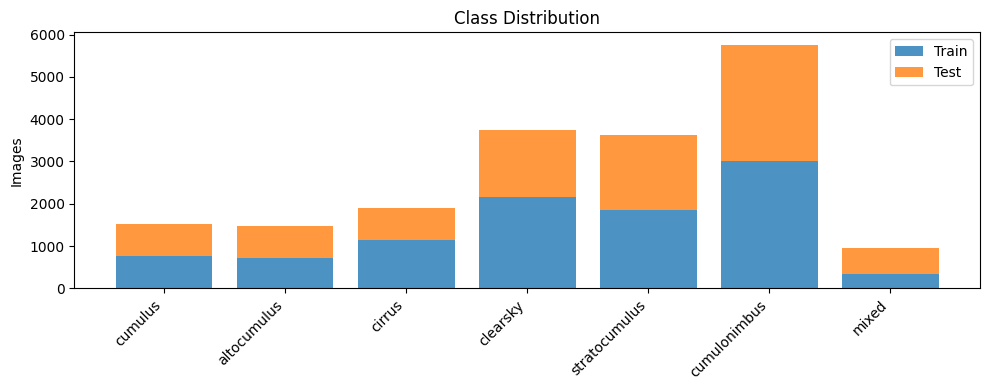

In [2]:
# =============================================================================
# CELL 2: Paths & Class Distribution
# =============================================================================
import os
import matplotlib.pyplot as plt
import numpy as np

# Paths
TRAIN_PATH = "/content/GCD_dataset/GCD/train"
TEST_PATH = "/content/GCD_dataset/GCD/test"

CLASS_NAMES = sorted([d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d))])
print(f"📊 Found {len(CLASS_NAMES)} classes:\n")

# Count images per class
def count_images(base_path):
    counts = {}
    for cls in CLASS_NAMES:
        cls_path = os.path.join(base_path, cls)
        counts[cls] = len([f for f in os.listdir(cls_path)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    return counts

train_counts = count_images(TRAIN_PATH)
test_counts = count_images(TEST_PATH)

# Display table
print(f"{'Class':<25} {'Train':>8} {'Test':>8} {'Total':>8} {'%':>7}")
print("-" * 58)
total_train, total_test = 0, 0
for cls in CLASS_NAMES:
    tr, te = train_counts[cls], test_counts[cls]
    total_train += tr
    total_test += te
    total = tr + te
    pct = total / 19000 * 100
    print(f"{cls:<25} {tr:>8} {te:>8} {total:>8} {pct:>6.1f}%")
print("-" * 58)
print(f"{'TOTAL':<25} {total_train:>8} {total_test:>8} {total_train+total_test:>8}")

# Imbalance ratio
counts_list = list(train_counts.values())
imbalance_ratio = max(counts_list) / min(counts_list)
print(f"\n📈 Imbalance ratio: {imbalance_ratio:.2f}x")
print(f"   (Max: {max(train_counts, key=train_counts.get)} = {max(counts_list)})")
print(f"   (Min: {min(train_counts, key=train_counts.get)} = {min(counts_list)})")

# Quick bar chart
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(CLASS_NAMES))
short_names = [c.split('_')[1] for c in CLASS_NAMES]  # Remove number prefix
ax.bar(x, [train_counts[c] for c in CLASS_NAMES], label='Train', alpha=0.8)
ax.bar(x, [test_counts[c] for c in CLASS_NAMES], bottom=[train_counts[c] for c in CLASS_NAMES], label='Test', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_ylabel('Images')
ax.set_title('Class Distribution')
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
# =============================================================================
# CELL 3: Image Quality & Resolution
# =============================================================================
from PIL import Image
from collections import defaultdict
import random

# Sample images from each class
resolutions = []
file_sizes = []
formats = defaultdict(int)
corrupted = []

print("🔍 Checking image quality (sampling 100 per class)...\n")

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(100, len(files)))

    for f in sample:
        fpath = os.path.join(cls_path, f)
        try:
            file_sizes.append(os.path.getsize(fpath) / 1024)  # KB
            with Image.open(fpath) as img:
                resolutions.append(img.size)
                formats[img.format] += 1
        except Exception as e:
            corrupted.append(f"{cls}/{f}")

# Results
unique_res = set(resolutions)
print(f"📏 RESOLUTION:")
print(f"   Unique resolutions: {len(unique_res)}")
for res in unique_res:
    count = resolutions.count(res)
    print(f"   {res[0]}×{res[1]}: {count} images ({count/len(resolutions)*100:.1f}%)")

print(f"\n📦 FILE SIZE:")
print(f"   Min: {min(file_sizes):.1f} KB")
print(f"   Max: {max(file_sizes):.1f} KB")
print(f"   Mean: {np.mean(file_sizes):.1f} KB")

print(f"\n🖼️ FORMAT: {dict(formats)}")
print(f"\n❌ CORRUPTED: {len(corrupted)} files")
if corrupted:
    for f in corrupted[:5]:
        print(f"   - {f}")

# Verdict
print("\n" + "="*50)
if len(unique_res) == 1 and (512, 512) in unique_res:
    print("✅ VERDICT: Perfect uniform 512×512 - no preprocessing needed!")
else:
    print("⚠️ VERDICT: Mixed resolutions - will need resizing")

🔍 Checking image quality (sampling 100 per class)...

📏 RESOLUTION:
   Unique resolutions: 1
   512×512: 700 images (100.0%)

📦 FILE SIZE:
   Min: 5.0 KB
   Max: 41.3 KB
   Mean: 13.1 KB

🖼️ FORMAT: {'JPEG': 700}

❌ CORRUPTED: 0 files

✅ VERDICT: Perfect uniform 512×512 - no preprocessing needed!


🎨 Analyzing color/brightness per class...

Class                     R      G      B   Bright    Std
-------------------------------------------------------
cumulus                98.6  150.2  201.4    150.0   14.6
altocumulus           117.1  162.3  212.7    164.0   27.2
cirrus                123.3  153.4  192.9    156.5   18.4
clearsky               78.8  136.3  202.6    139.2   21.7
stratocumulus         159.0  175.8  196.2    177.0   18.5
cumulonimbus          142.4  158.7  180.1    160.4   18.6
mixed                 132.9  168.1  210.7    170.6   14.3


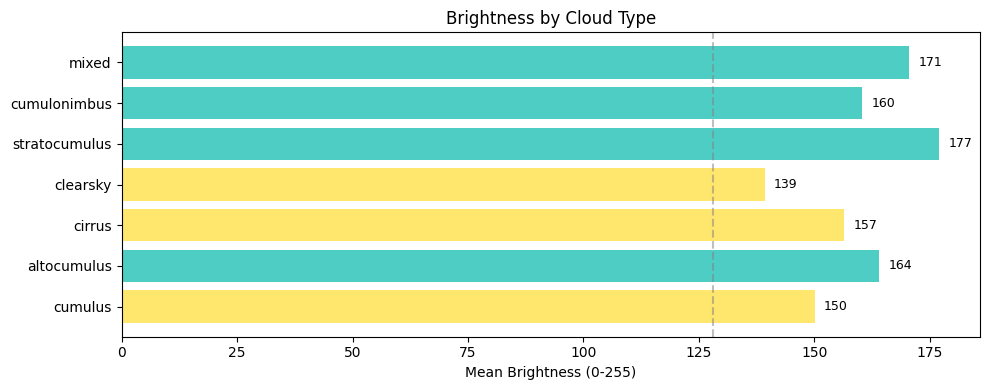


💡 INSIGHT:
   Darkest:   clearsky (139)
   Brightest: stratocumulus (177)


In [4]:
# =============================================================================
# CELL 4: Color & Brightness per Class
# =============================================================================
from PIL import Image
import numpy as np

print("🎨 Analyzing color/brightness per class...\n")

class_stats = {}

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(50, len(files)))

    r_vals, g_vals, b_vals, bright_vals = [], [], [], []

    for f in sample:
        try:
            with Image.open(os.path.join(cls_path, f)) as img:
                arr = np.array(img.convert('RGB'))
                r_vals.append(arr[:,:,0].mean())
                g_vals.append(arr[:,:,1].mean())
                b_vals.append(arr[:,:,2].mean())
                bright_vals.append(arr.mean())
        except:
            pass

    class_stats[cls] = {
        'R': np.mean(r_vals), 'G': np.mean(g_vals), 'B': np.mean(b_vals),
        'brightness': np.mean(bright_vals), 'bright_std': np.std(bright_vals)
    }

# Display table
print(f"{'Class':<20} {'R':>6} {'G':>6} {'B':>6} {'Bright':>8} {'Std':>6}")
print("-" * 55)
for cls in CLASS_NAMES:
    s = class_stats[cls]
    short = cls.split('_')[1][:15]
    print(f"{short:<20} {s['R']:>6.1f} {s['G']:>6.1f} {s['B']:>6.1f} {s['brightness']:>8.1f} {s['bright_std']:>6.1f}")

# Visual
fig, ax = plt.subplots(figsize=(10, 4))
short_names = [c.split('_')[1] for c in CLASS_NAMES]
brightnesses = [class_stats[c]['brightness'] for c in CLASS_NAMES]
colors = ['#ff6b6b' if b < 120 else '#4ecdc4' if b > 160 else '#ffe66d' for b in brightnesses]

bars = ax.barh(short_names, brightnesses, color=colors)
ax.axvline(x=128, color='gray', linestyle='--', alpha=0.5, label='Midpoint')
ax.set_xlabel('Mean Brightness (0-255)')
ax.set_title('Brightness by Cloud Type')

# Add value labels
for bar, val in zip(bars, brightnesses):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Quick insight
sorted_bright = sorted(class_stats.items(), key=lambda x: x[1]['brightness'])
print(f"\n💡 INSIGHT:")
print(f"   Darkest:   {sorted_bright[0][0].split('_')[1]} ({sorted_bright[0][1]['brightness']:.0f})")
print(f"   Brightest: {sorted_bright[-1][0].split('_')[1]} ({sorted_bright[-1][1]['brightness']:.0f})")

In [5]:
# =============================================================================
# CELL 5: Normalization Statistics (for PyTorch)
# =============================================================================
from PIL import Image
import numpy as np

print("📊 Calculating dataset normalization stats...\n")

pixel_sum = np.zeros(3)
pixel_sq_sum = np.zeros(3)
num_pixels = 0

# Sample from training set
for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(100, len(files)))

    for f in sample:
        try:
            with Image.open(os.path.join(cls_path, f)) as img:
                arr = np.array(img.convert('RGB')).astype(np.float32) / 255.0
                pixel_sum += arr.sum(axis=(0, 1))
                pixel_sq_sum += (arr ** 2).sum(axis=(0, 1))
                num_pixels += arr.shape[0] * arr.shape[1]
        except:
            pass

# Calculate mean and std
mean = pixel_sum / num_pixels
std = np.sqrt(pixel_sq_sum / num_pixels - mean ** 2)

print(f"TJNU-GCD Normalization Values:")
print(f"   Mean: [{mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}]")
print(f"   Std:  [{std[0]:.4f}, {std[1]:.4f}, {std[2]:.4f}]")

print(f"\n📋 Copy-paste for PyTorch:")
print(f"""
transforms.Normalize(
    mean=[{mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}],
    std=[{std[0]:.4f}, {std[1]:.4f}, {std[2]:.4f}]
)
""")

print(f"vs ImageNet: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]")
print(f"\n💡 TIP: Use ImageNet stats for transfer learning, dataset stats for training from scratch")

📊 Calculating dataset normalization stats...

TJNU-GCD Normalization Values:
   Mean: [0.4674, 0.6149, 0.7809]
   Std:  [0.2027, 0.1410, 0.1403]

📋 Copy-paste for PyTorch:

transforms.Normalize(
    mean=[0.4674, 0.6149, 0.7809],
    std=[0.2027, 0.1410, 0.1403]
)

vs ImageNet: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

💡 TIP: Use ImageNet stats for transfer learning, dataset stats for training from scratch


In [6]:
# =============================================================================
# CELL 6: Duplicate Detection
# =============================================================================
import hashlib
from collections import defaultdict

print("🔍 Checking for duplicates...\n")

# MD5 hash for exact duplicates
md5_dict = defaultdict(list)

for split_name, split_path in [("train", TRAIN_PATH), ("test", TEST_PATH)]:
    for cls in CLASS_NAMES:
        cls_path = os.path.join(split_path, cls)
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        for f in files:
            fpath = os.path.join(cls_path, f)
            try:
                with open(fpath, 'rb') as file:
                    md5 = hashlib.md5(file.read()).hexdigest()
                    md5_dict[md5].append((split_name, cls, f))
            except:
                pass

# Find duplicates
exact_dups = {k: v for k, v in md5_dict.items() if len(v) > 1}

# Categorize
within_class = []
cross_class = []
cross_split = []  # DANGEROUS: same image in train AND test

for hash_key, files in exact_dups.items():
    splits = set(s for s, c, f in files)
    classes = set(c for s, c, f in files)

    if len(splits) > 1:
        cross_split.append((hash_key, files))
    elif len(classes) > 1:
        cross_class.append((hash_key, files))
    else:
        within_class.append((hash_key, files))

total_dup_files = sum(len(v) - 1 for v in exact_dups.values())

print(f"📋 DUPLICATE ANALYSIS (all 19,000 images):")
print(f"   Total duplicate files: {total_dup_files}")
print(f"   Within same class: {len(within_class)} groups")
print(f"   Cross-class (label error?): {len(cross_class)} groups")
print(f"   Cross-split (data leak!): {len(cross_split)} groups")

if cross_split:
    print(f"\n🚨 DATA LEAKAGE DETECTED!")
    for h, files in cross_split[:3]:
        print(f"   Same image in:")
        for s, c, f in files:
            print(f"      - {s}/{c}/{f}")

if cross_class:
    print(f"\n⚠️ POTENTIAL LABELING ERRORS:")
    for h, files in cross_class[:3]:
        print(f"   Same image labeled as:")
        for s, c, f in files:
            print(f"      - {c}")

print(f"\n💡 VERDICT:", end=" ")
if cross_split:
    print("⚠️ Has train-test leakage - accuracy will be inflated!")
elif total_dup_files == 0:
    print("✅ No duplicates - clean dataset!")
elif total_dup_files < 100:
    print(f"✅ Minor duplicates ({total_dup_files}) - acceptable")
else:
    print(f"⚠️ Significant duplicates ({total_dup_files}) - consider cleaning")

🔍 Checking for duplicates...

📋 DUPLICATE ANALYSIS (all 19,000 images):
   Total duplicate files: 159
   Within same class: 3 groups
   Cross-class (label error?): 0 groups
   Cross-split (data leak!): 156 groups

🚨 DATA LEAKAGE DETECTED!
   Same image in:
      - train/4_clearsky/4_clearsky_000908.jpg
      - test/4_clearsky/4_clearsky_003218.jpg
   Same image in:
      - train/4_clearsky/4_clearsky_002006.jpg
      - test/4_clearsky/4_clearsky_003396.jpg
   Same image in:
      - train/4_clearsky/4_clearsky_001904.jpg
      - test/4_clearsky/4_clearsky_003297.jpg

💡 VERDICT: ⚠️ Has train-test leakage - accuracy will be inflated!


In [7]:
# =============================================================================
# CELL 7: Data Leakage Analysis & Fix
# =============================================================================

print("🔬 Analyzing data leakage in detail...\n")

# Count leakage per class
leakage_by_class = defaultdict(int)
leaked_test_files = []  # Files to remove from test

for hash_key, files in cross_split:
    # Find the test file(s) in this duplicate group
    for split, cls, fname in files:
        if split == "test":
            leakage_by_class[cls] += 1
            leaked_test_files.append((cls, fname))

print(f"📊 LEAKAGE BY CLASS:")
print(f"{'Class':<25} {'Leaked':>8} {'Test Total':>12} {'% Affected':>12}")
print("-" * 60)
for cls in CLASS_NAMES:
    leaked = leakage_by_class[cls]
    total = test_counts[cls]
    pct = leaked / total * 100 if total > 0 else 0
    flag = "⚠️" if pct > 2 else ""
    print(f"{cls:<25} {leaked:>8} {total:>12} {pct:>11.1f}% {flag}")
print("-" * 60)
print(f"{'TOTAL':<25} {len(leaked_test_files):>8} {sum(test_counts.values()):>12} {len(leaked_test_files)/sum(test_counts.values())*100:>11.1f}%")

# Impact on metrics
print(f"\n📈 IMPACT ON YOUR METRICS:")
print(f"   If model memorizes all leaked images:")
print(f"   → Free accuracy boost: +{len(leaked_test_files)/sum(test_counts.values())*100:.1f}%")
print(f"   → Your 95% accuracy might really be 93.3%")

# Save list for removal
print(f"\n💾 Saving leaked file list...")
with open('/content/leaked_test_files.txt', 'w') as f:
    for cls, fname in leaked_test_files:
        f.write(f"{cls}/{fname}\n")
print(f"   Saved: /content/leaked_test_files.txt ({len(leaked_test_files)} files)")

print(f"""
🛠️ HOW TO FIX (choose one):

Option A: Remove leaked files from test set
   - Clean test set: {sum(test_counts.values()) - len(leaked_test_files)} images
   - More honest accuracy

Option B: Create fresh 80/20 split ignoring original split
   - Shuffle all 19,000 images
   - Split with stratification
   - No leakage guaranteed

Option C: Keep as-is but report both metrics
   - "Accuracy on original split: X%"
   - "Accuracy excluding leaked images: Y%"
""")

🔬 Analyzing data leakage in detail...

📊 LEAKAGE BY CLASS:
Class                       Leaked   Test Total   % Affected
------------------------------------------------------------
1_cumulus                        0          750         0.0% 
2_altocumulus                    0          750         0.0% 
3_cirrus                         0          753         0.0% 
4_clearsky                     155         1589         9.8% ⚠️
5_stratocumulus                  0         1790         0.0% 
6_cumulonimbus                   0         2761         0.0% 
7_mixed                          1          607         0.2% 
------------------------------------------------------------
TOTAL                          156         9000         1.7%

📈 IMPACT ON YOUR METRICS:
   If model memorizes all leaked images:
   → Free accuracy boost: +1.7%
   → Your 95% accuracy might really be 93.3%

💾 Saving leaked file list...
   Saved: /content/leaked_test_files.txt (156 files)

🛠️ HOW TO FIX (choose one):

Opt

🖼️ Sample images from each class:



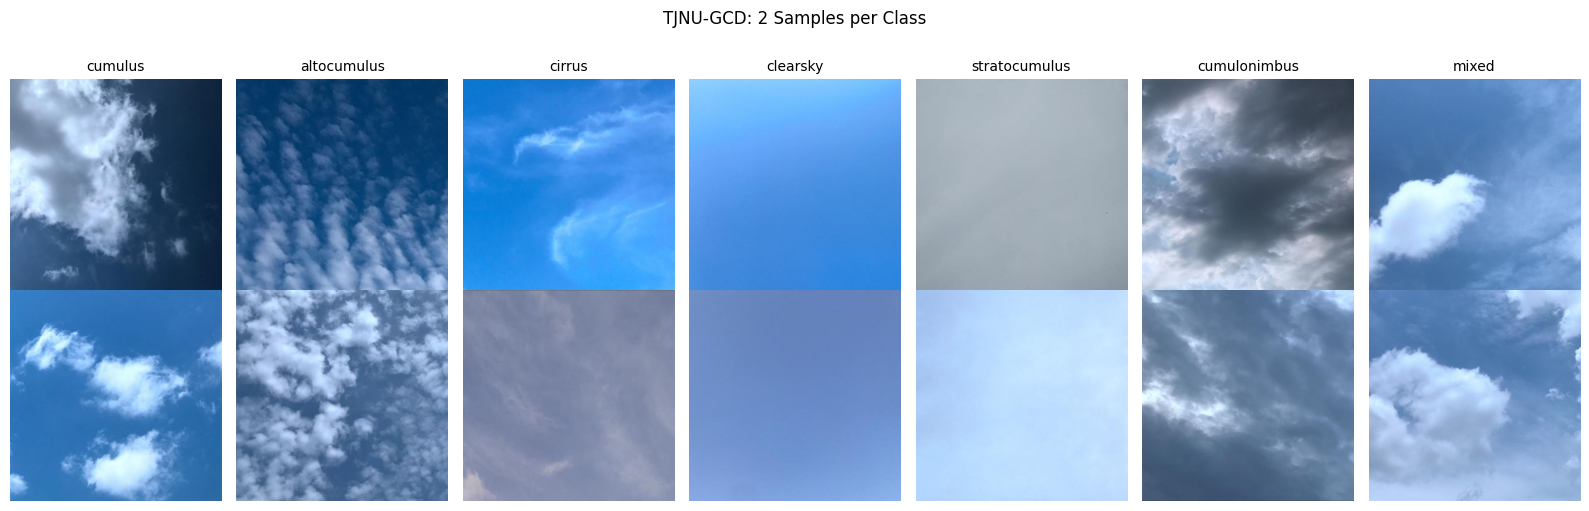

💾 Saved: /content/class_samples.png


In [8]:
# =============================================================================
# CELL 8: Visual Samples per Class
# =============================================================================
from PIL import Image
import matplotlib.pyplot as plt
import random

print("🖼️ Sample images from each class:\n")

fig, axes = plt.subplots(2, 7, figsize=(16, 5))

for idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Show 2 random samples per class
    samples = random.sample(files, min(2, len(files)))

    for row, f in enumerate(samples):
        img = Image.open(os.path.join(cls_path, f))
        axes[row, idx].imshow(img)
        axes[row, idx].axis('off')
        if row == 0:
            axes[row, idx].set_title(cls.split('_')[1], fontsize=10)

plt.suptitle('TJNU-GCD: 2 Samples per Class', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('/content/class_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: /content/class_samples.png")

In [9]:
# =============================================================================
# CELL 8: Document Leakage Finding (Decision for later)
# =============================================================================

summary = """
📋 DATA LEAKAGE FINDING - TJNU-GCD
==================================
Issue: 156 images appear in BOTH train and test sets
       - 155 in clearsky class (9.8% of clearsky test)
       - 1 in mixed class

Impact: ~1.7% inflated test accuracy

Decision needed before training:
  □ Option A: Remove 156 leaked files from test → clean 8,844 test images
  □ Option B: Create fresh stratified split from all 19,000
  □ Option C: Keep as-is, report both metrics

Recommendation: Option A (simplest, preserves most of original split)

File saved: /content/leaked_test_files.txt
"""
print(summary)

# Save summary
with open('/content/dataset_issues.txt', 'w') as f:
    f.write(summary)
print("💾 Saved: /content/dataset_issues.txt")


📋 DATA LEAKAGE FINDING - TJNU-GCD
Issue: 156 images appear in BOTH train and test sets
       - 155 in clearsky class (9.8% of clearsky test)
       - 1 in mixed class
       
Impact: ~1.7% inflated test accuracy

Decision needed before training:
  □ Option A: Remove 156 leaked files from test → clean 8,844 test images
  □ Option B: Create fresh stratified split from all 19,000
  □ Option C: Keep as-is, report both metrics
  
Recommendation: Option A (simplest, preserves most of original split)

File saved: /content/leaked_test_files.txt

💾 Saved: /content/dataset_issues.txt


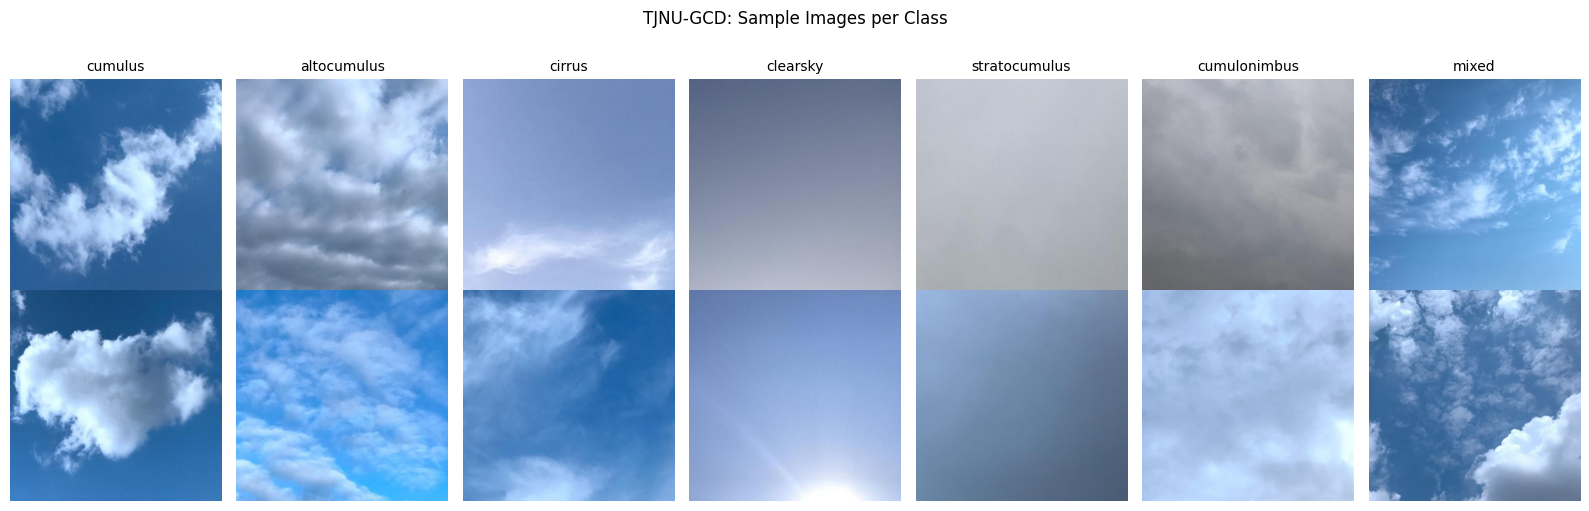

In [10]:
# =============================================================================
# CELL 9: Visual Samples per Class
# =============================================================================
from PIL import Image
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 7, figsize=(16, 5))

for idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    samples = random.sample(files, 2)

    for row, f in enumerate(samples):
        img = Image.open(os.path.join(cls_path, f))
        axes[row, idx].imshow(img)
        axes[row, idx].axis('off')
        if row == 0:
            axes[row, idx].set_title(cls.split('_')[1], fontsize=10)

plt.suptitle('TJNU-GCD: Sample Images per Class', y=1.02)
plt.tight_layout()
plt.show()


In [11]:
# =============================================================================
# CELL 10: Class Separability Test
# =============================================================================
from PIL import Image
import numpy as np
from collections import defaultdict

print("📊 Testing class separability with simple features...\n")

# Extract simple features: mean RGB + brightness + std
features_by_class = defaultdict(list)

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(100, len(files)))

    for f in sample:
        try:
            with Image.open(os.path.join(cls_path, f)) as img:
                arr = np.array(img.convert('RGB')).astype(float)
                feat = [
                    arr[:,:,0].mean(),  # R
                    arr[:,:,1].mean(),  # G
                    arr[:,:,2].mean(),  # B
                    arr.std(),          # Overall texture
                ]
                features_by_class[cls].append(feat)
        except:
            pass

# Calculate class centroids and spread
print(f"{'Class':<20} {'R':>6} {'G':>6} {'B':>6} {'Texture':>8}")
print("-" * 50)
centroids = {}
for cls in CLASS_NAMES:
    feats = np.array(features_by_class[cls])
    centroid = feats.mean(axis=0)
    centroids[cls] = centroid
    short = cls.split('_')[1][:15]
    print(f"{short:<20} {centroid[0]:>6.1f} {centroid[1]:>6.1f} {centroid[2]:>6.1f} {centroid[3]:>8.1f}")

# Calculate pairwise distances between class centroids
print(f"\n📏 PAIRWISE CLASS DISTANCES (higher = more separable):")
print(f"{'Pair':<35} {'Distance':>10}")
print("-" * 47)

distances = []
for i, cls1 in enumerate(CLASS_NAMES):
    for cls2 in CLASS_NAMES[i+1:]:
        dist = np.linalg.norm(centroids[cls1] - centroids[cls2])
        distances.append((cls1.split('_')[1], cls2.split('_')[1], dist))

# Sort by distance
distances.sort(key=lambda x: x[2])

print("Most likely to confuse (smallest distance):")
for c1, c2, d in distances[:3]:
    print(f"  {c1:<15} ↔ {c2:<15} {d:>10.1f} ⚠️")

print("\nEasiest to distinguish (largest distance):")
for c1, c2, d in distances[-3:]:
    print(f"  {c1:<15} ↔ {c2:<15} {d:>10.1f} ✅")

📊 Testing class separability with simple features...

Class                     R      G      B  Texture
--------------------------------------------------
cumulus                99.2  154.2  207.9     64.1
altocumulus           109.8  157.2  209.1     51.7
cirrus                117.0  148.6  190.3     38.2
clearsky               76.6  136.6  204.0     54.8
stratocumulus         157.8  175.5  196.0     21.6
cumulonimbus          145.6  161.8  183.2     25.8
mixed                 130.0  165.2  208.2     45.7

📏 PAIRWISE CLASS DISTANCES (higher = more separable):
Pair                                  Distance
-----------------------------------------------
Most likely to confuse (smallest distance):
  cumulus         ↔ altocumulus           16.7 ⚠️
  altocumulus     ↔ mixed                 22.6 ⚠️
  stratocumulus   ↔ cumulonimbus          22.8 ⚠️

Easiest to distinguish (largest distance):
  cumulus         ↔ stratocumulus         76.4 ✅
  clearsky        ↔ cumulonimbus          81.7 ✅
 

In [12]:
# =============================================================================
# CELL 11: Complete Dataset Summary
# =============================================================================

print("=" * 70)
print("📋 TJNU-GCD DATASET ANALYSIS SUMMARY")
print("=" * 70)

summary = f"""
┌─────────────────────────────────────────────────────────────────────┐
│  BASIC INFO                                                         │
├─────────────────────────────────────────────────────────────────────┤
│  Total images:     19,000                                           │
│  Train / Test:     10,000 / 9,000                                   │
│  Classes:          7                                                │
│  Resolution:       512×512 (uniform) ✅                             │
│  Format:           JPEG                                             │
│  Source:           9 provinces, China (2019-2020)                   │
│  Annotators:       Meteorologists + researchers                     │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  DATA QUALITY SCORES                                                │
├─────────────────────────────────────────────────────────────────────┤
│  Resolution consistency:    100%  ✅ (all 512×512)                  │
│  Corrupted files:           0     ✅                                │
│  Class imbalance ratio:     8.63x ⚠️  (cumulonimbus dominates)      │
│  Data leakage:              156 files (1.7%) ⚠️                     │
│  Cross-class duplicates:    0     ✅                                │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  CLASS DISTRIBUTION                                                 │
├─────────────────────────────────────────────────────────────────────┤
│  6_cumulonimbus:     5,764  (30.3%) ████████████████                │
│  4_clearsky:         3,739  (19.7%) ██████████                      │
│  5_stratocumulus:    3,636  (19.1%) ██████████                      │
│  3_cirrus:           1,906  (10.0%) █████                           │
│  1_cumulus:          1,525  ( 8.0%) ████                            │
│  2_altocumulus:      1,475  ( 7.8%) ████                            │
│  7_mixed:              955  ( 5.0%) ██                              │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  PREDICTED DIFFICULT PAIRS (model will confuse)                     │
├─────────────────────────────────────────────────────────────────────┤
│  1. Cumulus ↔ Altocumulus        (both puffy white)                 │
│  2. Stratocumulus ↔ Cumulonimbus (both gray overcast)               │
│  3. Altocumulus ↔ Mixed          (visual overlap)                   │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  NORMALIZATION VALUES (for PyTorch)                                 │
├─────────────────────────────────────────────────────────────────────┤
│  mean = [0.4674, 0.6149, 0.7809]                                    │
│  std  = [0.2027, 0.1410, 0.1403]                                    │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  ISSUES TO ADDRESS BEFORE TRAINING                                  │
├─────────────────────────────────────────────────────────────────────┤
│  1. Data leakage: Remove 156 files from test (mostly clearsky)      │
│  2. Class imbalance: Use weighted loss or oversampling              │
│  3. Verify: Run on held-out data excluding leaked images            │
└─────────────────────────────────────────────────────────────────────┘
"""
print(summary)

# Comparison with CCSN
print("=" * 70)
print("📊 COMPARISON: TJNU-GCD vs CCSN")
print("=" * 70)
comparison = """
┌──────────────────────┬─────────────────┬─────────────────┐
│  Metric              │  CCSN           │  TJNU-GCD       │
├──────────────────────┼─────────────────┼─────────────────┤
│  Total images        │  2,543          │  19,000  ✅     │
│  Classes             │  11             │  7              │
│  Resolution          │  Mixed          │  512×512 ✅     │
│  Pre-split           │  No             │  Yes ✅         │
│  Imbalance ratio     │  2.5x           │  8.63x ⚠️       │
│  Data leakage        │  Unknown        │  1.7% ⚠️        │
│  Annotators          │  Unknown        │  Experts ✅     │
├──────────────────────┼─────────────────┼─────────────────┤
│  VERDICT             │  Good for       │  Better for     │
│                      │  prototyping    │  production     │
└──────────────────────┴─────────────────┴─────────────────┘
"""
print(comparison)

print("💾 Saving summary...")
with open('/content/TJNU_GCD_summary.txt', 'w') as f:
    f.write(summary)
    f.write("\n\n")
    f.write(comparison)
print("   Saved: /content/TJNU_GCD_summary.txt")

📋 TJNU-GCD DATASET ANALYSIS SUMMARY

┌─────────────────────────────────────────────────────────────────────┐
│  BASIC INFO                                                         │
├─────────────────────────────────────────────────────────────────────┤
│  Total images:     19,000                                           │
│  Train / Test:     10,000 / 9,000                                   │
│  Classes:          7                                                │
│  Resolution:       512×512 (uniform) ✅                             │
│  Format:           JPEG                                             │
│  Source:           9 provinces, China (2019-2020)                   │
│  Annotators:       Meteorologists + researchers                     │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  DATA QUALITY SCORES                                                │
├──────────────────────────

🔬 Analyzing texture patterns per class...

Class                  Edge Score     Contrast Interpretation           
---------------------------------------------------------------------------
cumulus                     3.8 ± 0.8     46.3 ± 9.3   Low detail (smooth/uniform)
altocumulus                 4.8 ± 1.6     29.0 ± 11.1  Low detail (smooth/uniform)
cirrus                      2.6 ± 0.7     20.2 ± 10.2  Low detail (smooth/uniform)
clearsky                    2.0 ± 0.4     12.2 ± 7.5   Low detail (smooth/uniform)
stratocumulus               2.3 ± 0.4     11.7 ± 5.7   Low detail (smooth/uniform)
cumulonimbus                2.4 ± 0.5     16.9 ± 8.4   Low detail (smooth/uniform)
mixed                       4.3 ± 1.2     32.7 ± 8.8   Low detail (smooth/uniform)


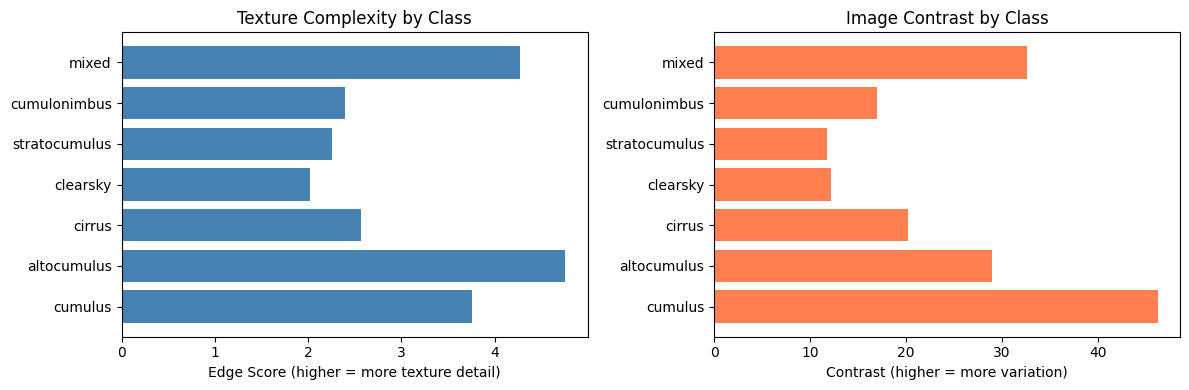


💡 INSIGHT:
   High edge score = Sharp boundaries (puffy clouds like cumulus)
   Low edge score  = Smooth/uniform (overcast like stratocumulus)
   
   This explains why stratocumulus ↔ cumulonimbus confuse: both have LOW texture!



In [13]:
# =============================================================================
# CELL 12: Texture Analysis using Edge Detection
# =============================================================================
from PIL import Image, ImageFilter
import numpy as np

print("🔬 Analyzing texture patterns per class...\n")

texture_stats = {}

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(80, len(files)))

    edge_scores = []
    contrast_scores = []

    for f in sample:
        try:
            with Image.open(os.path.join(cls_path, f)) as img:
                gray = img.convert('L')

                # Edge detection (Sobel-like via built-in filter)
                edges = gray.filter(ImageFilter.FIND_EDGES)
                edge_score = np.array(edges).mean()
                edge_scores.append(edge_score)

                # Local contrast (standard deviation in patches)
                arr = np.array(gray)
                contrast_scores.append(arr.std())
        except:
            pass

    texture_stats[cls] = {
        'edge_mean': np.mean(edge_scores),
        'edge_std': np.std(edge_scores),
        'contrast_mean': np.mean(contrast_scores),
        'contrast_std': np.std(contrast_scores)
    }

# Display
print(f"{'Class':<20} {'Edge Score':>12} {'Contrast':>12} {'Interpretation':<25}")
print("-" * 75)

for cls in CLASS_NAMES:
    s = texture_stats[cls]
    short = cls.split('_')[1]

    # Interpret texture
    if s['edge_mean'] > 25:
        interp = "High detail (sharp edges)"
    elif s['edge_mean'] > 15:
        interp = "Medium detail"
    else:
        interp = "Low detail (smooth/uniform)"

    print(f"{short:<20} {s['edge_mean']:>10.1f} ± {s['edge_std']:<5.1f} {s['contrast_mean']:>6.1f} ± {s['contrast_std']:<5.1f} {interp}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

short_names = [c.split('_')[1] for c in CLASS_NAMES]
edge_means = [texture_stats[c]['edge_mean'] for c in CLASS_NAMES]
contrast_means = [texture_stats[c]['contrast_mean'] for c in CLASS_NAMES]

axes[0].barh(short_names, edge_means, color='steelblue')
axes[0].set_xlabel('Edge Score (higher = more texture detail)')
axes[0].set_title('Texture Complexity by Class')

axes[1].barh(short_names, contrast_means, color='coral')
axes[1].set_xlabel('Contrast (higher = more variation)')
axes[1].set_title('Image Contrast by Class')

plt.tight_layout()
plt.show()

print(f"""
💡 INSIGHT:
   High edge score = Sharp boundaries (puffy clouds like cumulus)
   Low edge score  = Smooth/uniform (overcast like stratocumulus)

   This explains why stratocumulus ↔ cumulonimbus confuse: both have LOW texture!
""")

📍 Analyzing spatial patterns (where are clouds located?)...



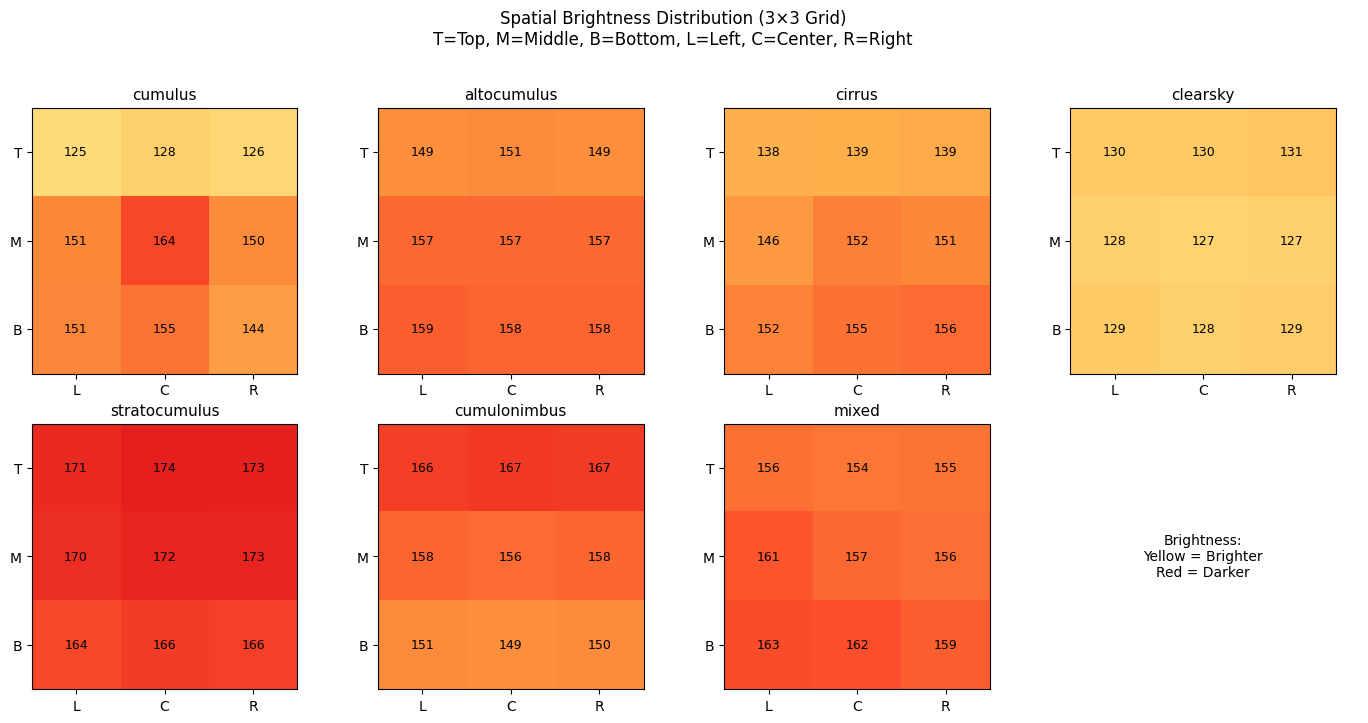

📊 CENTER vs EDGE brightness (clouds often in center):

Class                    Center    Edges Avg       Diff Pattern             
-----------------------------------------------------------------
cumulus                   163.9        141.3      +22.6 Center-bright ☀️
altocumulus               156.6        154.7       +1.9 Uniform ▢
cirrus                    152.4        147.1       +5.3 Uniform ▢
clearsky                  126.8        129.0       -2.2 Uniform ▢
stratocumulus             172.3        169.6       +2.7 Uniform ▢
cumulonimbus              156.3        158.3       -2.1 Uniform ▢
mixed                     157.3        158.3       -0.9 Uniform ▢


In [14]:
# =============================================================================
# CELL 13: Spatial Analysis - Where do clouds appear?
# =============================================================================
from PIL import Image
import numpy as np

print("📍 Analyzing spatial patterns (where are clouds located?)...\n")

# Divide image into 3x3 grid, measure brightness per region
spatial_patterns = {}

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(100, len(files)))

    grid_sums = np.zeros((3, 3))
    count = 0

    for f in sample:
        try:
            with Image.open(os.path.join(cls_path, f)) as img:
                arr = np.array(img.convert('L'))  # Grayscale
                h, w = arr.shape

                # Split into 3x3 grid
                for i in range(3):
                    for j in range(3):
                        region = arr[i*h//3:(i+1)*h//3, j*w//3:(j+1)*w//3]
                        grid_sums[i, j] += region.mean()
                count += 1
        except:
            pass

    spatial_patterns[cls] = grid_sums / count if count > 0 else grid_sums

# Visualize as heatmaps
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for idx, cls in enumerate(CLASS_NAMES):
    im = axes[idx].imshow(spatial_patterns[cls], cmap='YlOrRd', vmin=100, vmax=200)
    axes[idx].set_title(cls.split('_')[1], fontsize=11)
    axes[idx].set_xticks([0, 1, 2])
    axes[idx].set_xticklabels(['L', 'C', 'R'])
    axes[idx].set_yticks([0, 1, 2])
    axes[idx].set_yticklabels(['T', 'M', 'B'])

    # Add values
    for i in range(3):
        for j in range(3):
            val = spatial_patterns[cls][i, j]
            axes[idx].text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=9)

# Hide last empty subplot
axes[7].axis('off')
axes[7].text(0.5, 0.5, 'Brightness:\nYellow = Brighter\nRed = Darker',
             ha='center', va='center', fontsize=10, transform=axes[7].transAxes)

plt.suptitle('Spatial Brightness Distribution (3×3 Grid)\nT=Top, M=Middle, B=Bottom, L=Left, C=Center, R=Right', y=1.02)
plt.tight_layout()
plt.show()

# Analyze center vs edges
print("📊 CENTER vs EDGE brightness (clouds often in center):\n")
print(f"{'Class':<20} {'Center':>10} {'Edges Avg':>12} {'Diff':>10} {'Pattern':<20}")
print("-" * 65)

for cls in CLASS_NAMES:
    grid = spatial_patterns[cls]
    center = grid[1, 1]
    edges = (grid[0, :].sum() + grid[2, :].sum() + grid[1, 0] + grid[1, 2]) / 8
    diff = center - edges

    if diff > 10:
        pattern = "Center-bright ☀️"
    elif diff < -10:
        pattern = "Center-dark 🌑"
    else:
        pattern = "Uniform ▢"

    short = cls.split('_')[1]
    print(f"{short:<20} {center:>10.1f} {edges:>12.1f} {diff:>+10.1f} {pattern}")

🎯 Predicting model confusion based on feature overlap...

📊 PREDICTED CONFUSION MATRIX
   (% of samples closer to wrong class centroid)



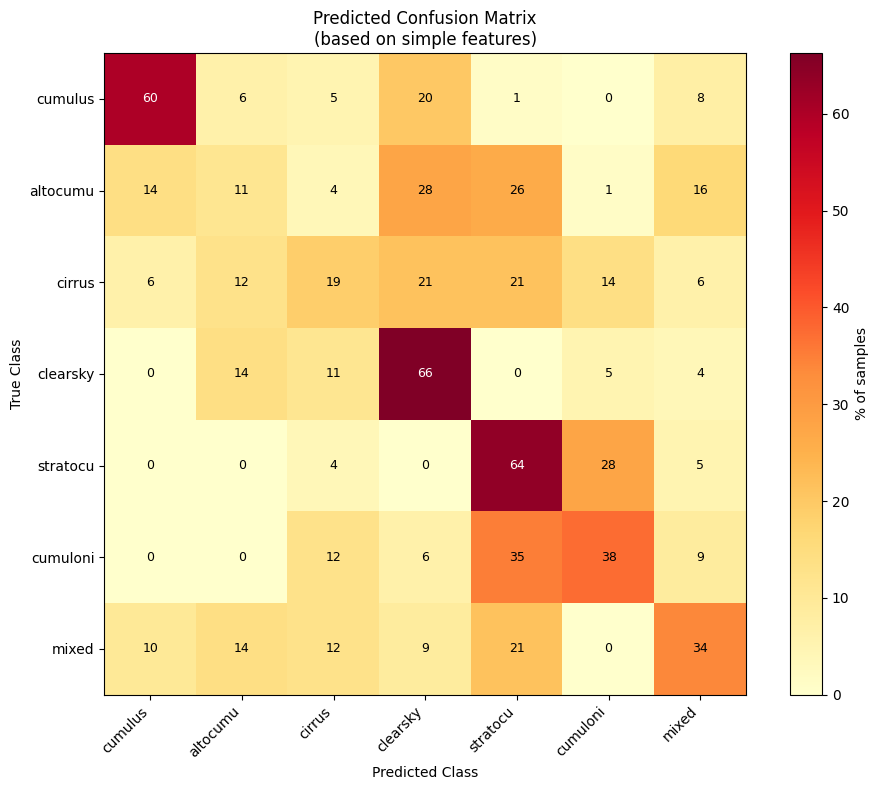


⚠️ TOP PREDICTED CONFUSIONS (off-diagonal):
   cumulonimbus    → stratocumulus   (35.0%)
   altocumulus     → clearsky        (27.5%)
   stratocumulus   → cumulonimbus    (27.5%)
   altocumulus     → stratocumulus   (26.2%)
   cirrus          → clearsky        (21.2%)
   cirrus          → stratocumulus   (21.2%)
   mixed           → stratocumulus   (21.2%)
   cumulus         → clearsky        (20.0%)


In [15]:
# =============================================================================
# CELL 14: Predict Which Classes Will Confuse Each Other
# =============================================================================
import numpy as np
from scipy.spatial.distance import cdist

print("🎯 Predicting model confusion based on feature overlap...\n")

# Collect all features per class
all_features = {}

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(80, len(files)))

    features = []
    for f in sample:
        try:
            with Image.open(os.path.join(cls_path, f)) as img:
                arr = np.array(img.convert('RGB')).astype(float)
                gray = np.array(img.convert('L')).astype(float)

                feat = [
                    arr[:,:,0].mean(),           # R mean
                    arr[:,:,1].mean(),           # G mean
                    arr[:,:,2].mean(),           # B mean
                    arr.std(),                   # Overall std
                    gray[256, 256],              # Center pixel
                    gray[:171, :].mean(),        # Top third
                    gray[341:, :].mean(),        # Bottom third
                    np.array(img.convert('L').filter(ImageFilter.FIND_EDGES)).mean()  # Edge score
                ]
                features.append(feat)
        except:
            pass

    all_features[cls] = np.array(features)

# Calculate overlap: how many samples from class A are closer to class B's centroid than A's?
print("📊 PREDICTED CONFUSION MATRIX")
print("   (% of samples closer to wrong class centroid)\n")

centroids = {cls: all_features[cls].mean(axis=0) for cls in CLASS_NAMES}
short_names = [c.split('_')[1][:8] for c in CLASS_NAMES]

# Build confusion prediction matrix
confusion_pred = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)))

for i, cls_true in enumerate(CLASS_NAMES):
    samples = all_features[cls_true]
    true_centroid = centroids[cls_true]

    for sample in samples:
        # Find nearest centroid
        distances = [np.linalg.norm(sample - centroids[c]) for c in CLASS_NAMES]
        nearest = np.argmin(distances)
        confusion_pred[i, nearest] += 1

    # Normalize to percentages
    confusion_pred[i] = confusion_pred[i] / len(samples) * 100

# Display as heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confusion_pred, cmap='YlOrRd')

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_yticklabels(short_names)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title('Predicted Confusion Matrix\n(based on simple features)')

# Add values
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        val = confusion_pred[i, j]
        color = 'white' if val > 50 else 'black'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, label='% of samples')
plt.tight_layout()
plt.show()

# Identify worst confusions
print("\n⚠️ TOP PREDICTED CONFUSIONS (off-diagonal):")
confusions = []
for i, cls_true in enumerate(CLASS_NAMES):
    for j, cls_pred in enumerate(CLASS_NAMES):
        if i != j and confusion_pred[i, j] > 5:  # More than 5%
            confusions.append((cls_true.split('_')[1], cls_pred.split('_')[1], confusion_pred[i, j]))

confusions.sort(key=lambda x: -x[2])
for true, pred, pct in confusions[:8]:
    print(f"   {true:<15} → {pred:<15} ({pct:.1f}%)")

📊 Analyzing variation WITHIN each class...

   (High variation = harder to learn, needs more data)

Class                   Variation   Max Spread    Samples Assessment          
------------------------------------------------------------------------------
clearsky                     72.8        192.0       2150 ✓ High var, enough data
cirrus                       70.2        262.4       1153 ✓ High var, enough data
altocumulus                  67.3        200.7        725 ⚠️ High var, low data
stratocumulus                55.7        173.5       1846 ✓ High var, enough data
cumulus                      55.3        168.3        775 ⚠️ High var, low data
cumulonimbus                 54.3        164.8       3003 ✓ High var, enough data
mixed                        48.2        184.2        348 ⚠️ Low data


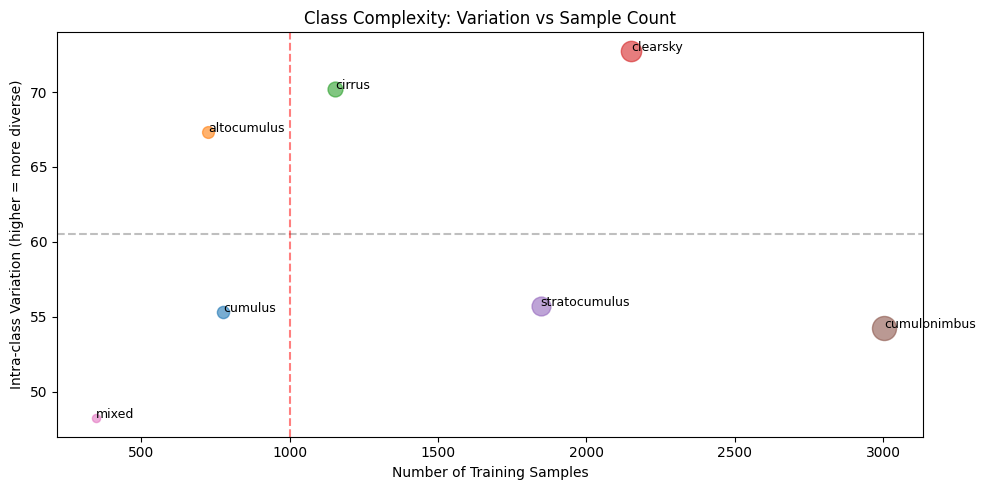


💡 INTERPRETATION:
   - Top-right: High variation + enough data = ✅ Good
   - Top-left:  High variation + few samples = ⚠️ Needs augmentation
   - Bottom-left: Low variation + few samples = ⚠️ Might overfit



In [16]:
# =============================================================================
# CELL 15: Intra-class Variation (How diverse is each class?)
# =============================================================================
from PIL import Image
import numpy as np
from scipy.spatial.distance import pdist

print("📊 Analyzing variation WITHIN each class...\n")
print("   (High variation = harder to learn, needs more data)\n")

intra_class_stats = {}

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(100, len(files)))

    features = []
    for f in sample:
        try:
            with Image.open(os.path.join(cls_path, f)) as img:
                arr = np.array(img.convert('RGB')).astype(float)
                feat = [
                    arr[:,:,0].mean(), arr[:,:,1].mean(), arr[:,:,2].mean(),
                    arr.std(), arr[:,:,0].std(), arr[:,:,1].std(), arr[:,:,2].std()
                ]
                features.append(feat)
        except:
            pass

    features = np.array(features)

    # Calculate pairwise distances within class
    if len(features) > 1:
        distances = pdist(features, metric='euclidean')
        intra_class_stats[cls] = {
            'mean_dist': np.mean(distances),
            'std_dist': np.std(distances),
            'max_dist': np.max(distances),
            'n_samples': train_counts[cls]
        }

# Display
print(f"{'Class':<20} {'Variation':>12} {'Max Spread':>12} {'Samples':>10} {'Assessment':<20}")
print("-" * 78)

variations = [(cls, intra_class_stats[cls]['mean_dist']) for cls in CLASS_NAMES]
variations.sort(key=lambda x: -x[1])

for cls, _ in variations:
    s = intra_class_stats[cls]
    short = cls.split('_')[1]

    # Assessment based on variation vs sample count
    var_per_sample = s['mean_dist'] / (s['n_samples'] ** 0.5)  # Normalized
    if s['mean_dist'] > 50 and s['n_samples'] < 1000:
        assessment = "⚠️ High var, low data"
    elif s['mean_dist'] > 50:
        assessment = "✓ High var, enough data"
    elif s['n_samples'] < 500:
        assessment = "⚠️ Low data"
    else:
        assessment = "✅ Good"

    print(f"{short:<20} {s['mean_dist']:>12.1f} {s['max_dist']:>12.1f} {s['n_samples']:>10} {assessment}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))

classes = [c.split('_')[1] for c in CLASS_NAMES]
variations = [intra_class_stats[c]['mean_dist'] for c in CLASS_NAMES]
samples = [intra_class_stats[c]['n_samples'] for c in CLASS_NAMES]

# Bubble chart: x=samples, y=variation, size=samples
colors = plt.cm.tab10(range(len(CLASS_NAMES)))
for i, cls in enumerate(CLASS_NAMES):
    ax.scatter(samples[i], variations[i], s=samples[i]/10, c=[colors[i]],
               alpha=0.6, label=classes[i])
    ax.annotate(classes[i], (samples[i], variations[i]), fontsize=9)

ax.set_xlabel('Number of Training Samples')
ax.set_ylabel('Intra-class Variation (higher = more diverse)')
ax.set_title('Class Complexity: Variation vs Sample Count')
ax.axhline(y=np.mean(variations), color='gray', linestyle='--', alpha=0.5, label='Avg variation')
ax.axvline(x=1000, color='red', linestyle='--', alpha=0.5, label='1000 samples threshold')

plt.tight_layout()
plt.show()

print("""
💡 INTERPRETATION:
   - Top-right: High variation + enough data = ✅ Good
   - Top-left:  High variation + few samples = ⚠️ Needs augmentation
   - Bottom-left: Low variation + few samples = ⚠️ Might overfit
""")

☀️ Analyzing brightness distribution per class...

Class                     Min      Max     Mean      Std    Range
-----------------------------------------------------------------
cumulus                  74.5    188.6    139.5     18.1    114.1
altocumulus              84.0    206.3    151.8     24.8    122.4
cirrus                   82.4    198.1    148.6     20.1    115.7
clearsky                 53.9    185.3    126.6     25.0    131.4
stratocumulus           130.3    214.1    172.0     17.0     83.8
cumulonimbus             74.9    189.7    155.4     18.5    114.8
mixed                   110.9    201.2    159.6     15.5     90.3


/tmp/ipython-input-2976682749.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(box_data, labels=short_names, patch_artist=True)


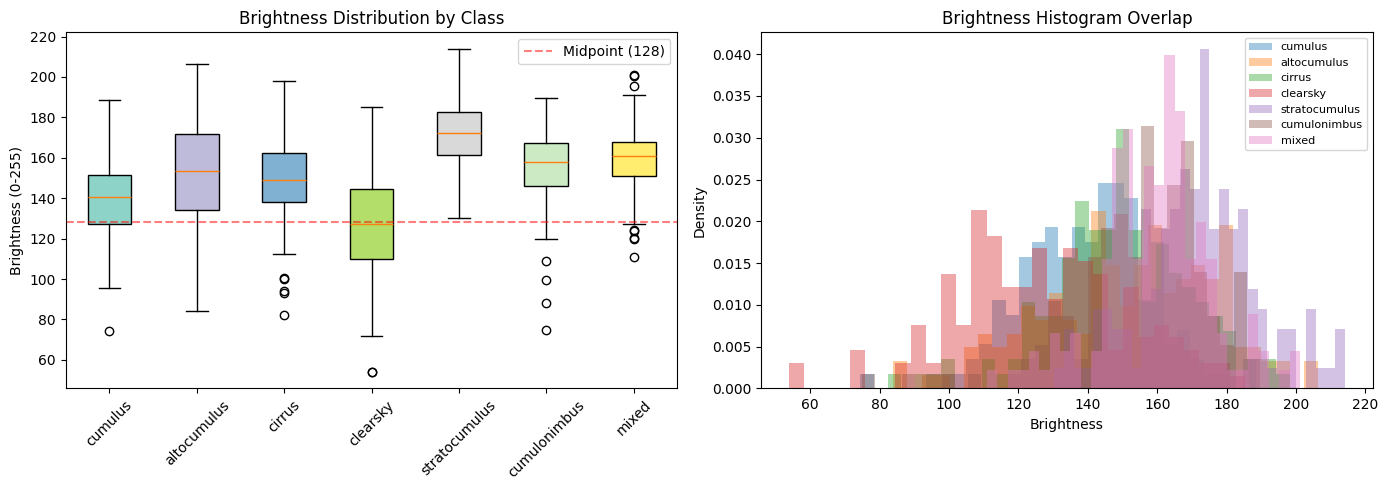


📊 BRIGHTNESS OVERLAP ANALYSIS:
   (How much do brightness ranges overlap between classes?)

Class Pair                             Overlap % Separable?     
-----------------------------------------------------------------
cirrus          ↔ cumulonimbus          78.5% ❌ No
altocumulus     ↔ cirrus                76.7% ❌ No
cumulonimbus    ↔ mixed                 75.3% ❌ No
altocumulus     ↔ cumulonimbus          70.3% ❌ No
cumulus         ↔ clearsky              68.7% ⚠️ Partial
cumulus         ↔ altocumulus           68.7% ⚠️ Partial
cumulus         ↔ cirrus                65.6% ⚠️ Partial

💡 KEY INSIGHT:
   High overlap % = Brightness alone cannot distinguish these classes
   → Model must learn TEXTURE and SHAPE features instead



In [17]:
# =============================================================================
# CELL 16: Brightness Distribution Deep Dive
# =============================================================================
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

print("☀️ Analyzing brightness distribution per class...\n")

brightness_data = {cls: [] for cls in CLASS_NAMES}

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(150, len(files)))

    for f in sample:
        try:
            with Image.open(os.path.join(cls_path, f)) as img:
                brightness = np.array(img.convert('L')).mean()
                brightness_data[cls].append(brightness)
        except:
            pass

# Statistics
print(f"{'Class':<20} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8} {'Range':>8}")
print("-" * 65)
for cls in CLASS_NAMES:
    data = brightness_data[cls]
    short = cls.split('_')[1]
    print(f"{short:<20} {min(data):>8.1f} {max(data):>8.1f} {np.mean(data):>8.1f} {np.std(data):>8.1f} {max(data)-min(data):>8.1f}")

# Box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
short_names = [c.split('_')[1] for c in CLASS_NAMES]
box_data = [brightness_data[c] for c in CLASS_NAMES]
bp = axes[0].boxplot(box_data, labels=short_names, patch_artist=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(CLASS_NAMES)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel('Brightness (0-255)')
axes[0].set_title('Brightness Distribution by Class')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=128, color='red', linestyle='--', alpha=0.5, label='Midpoint (128)')
axes[0].legend()

# Histogram overlay
for cls in CLASS_NAMES:
    axes[1].hist(brightness_data[cls], bins=30, alpha=0.4, label=cls.split('_')[1], density=True)
axes[1].set_xlabel('Brightness')
axes[1].set_ylabel('Density')
axes[1].set_title('Brightness Histogram Overlap')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Overlap analysis
print("\n📊 BRIGHTNESS OVERLAP ANALYSIS:")
print("   (How much do brightness ranges overlap between classes?)\n")

ranges = {}
for cls in CLASS_NAMES:
    data = brightness_data[cls]
    # Use 10th-90th percentile for robust range
    ranges[cls] = (np.percentile(data, 10), np.percentile(data, 90))

# Find overlapping pairs
print(f"{'Class Pair':<35} {'Overlap %':>12} {'Separable?':<15}")
print("-" * 65)

overlaps = []
for i, cls1 in enumerate(CLASS_NAMES):
    for cls2 in CLASS_NAMES[i+1:]:
        r1, r2 = ranges[cls1], ranges[cls2]

        # Calculate overlap
        overlap_start = max(r1[0], r2[0])
        overlap_end = min(r1[1], r2[1])

        if overlap_start < overlap_end:
            overlap_range = overlap_end - overlap_start
            total_range = max(r1[1], r2[1]) - min(r1[0], r2[0])
            overlap_pct = (overlap_range / total_range) * 100
        else:
            overlap_pct = 0

        overlaps.append((cls1.split('_')[1], cls2.split('_')[1], overlap_pct))

overlaps.sort(key=lambda x: -x[2])

for c1, c2, pct in overlaps[:7]:
    separable = "❌ No" if pct > 70 else "⚠️ Partial" if pct > 40 else "✅ Yes"
    print(f"{c1:<15} ↔ {c2:<15} {pct:>10.1f}% {separable}")

print("""
💡 KEY INSIGHT:
   High overlap % = Brightness alone cannot distinguish these classes
   → Model must learn TEXTURE and SHAPE features instead
""")

☁️ Analyzing cloud coverage (% of sky covered by clouds)...

Class                     Min      Max     Mean      Std Interpretation           
-------------------------------------------------------------------------------------
cumulus                 24.5%    62.1%    42.4%     8.6% Partial cloud cover
altocumulus             34.5%    61.5%    47.9%     6.1% Partial cloud cover
cirrus                  27.3%    67.3%    48.0%     6.4% Partial cloud cover
clearsky                25.1%    61.1%    43.6%     6.4% Partial cloud cover
stratocumulus           27.6%    68.0%    51.3%     7.0% Partial cloud cover
cumulonimbus            34.4%    59.7%    48.8%     5.3% Partial cloud cover
mixed                   32.6%    64.0%    47.1%     5.9% Partial cloud cover


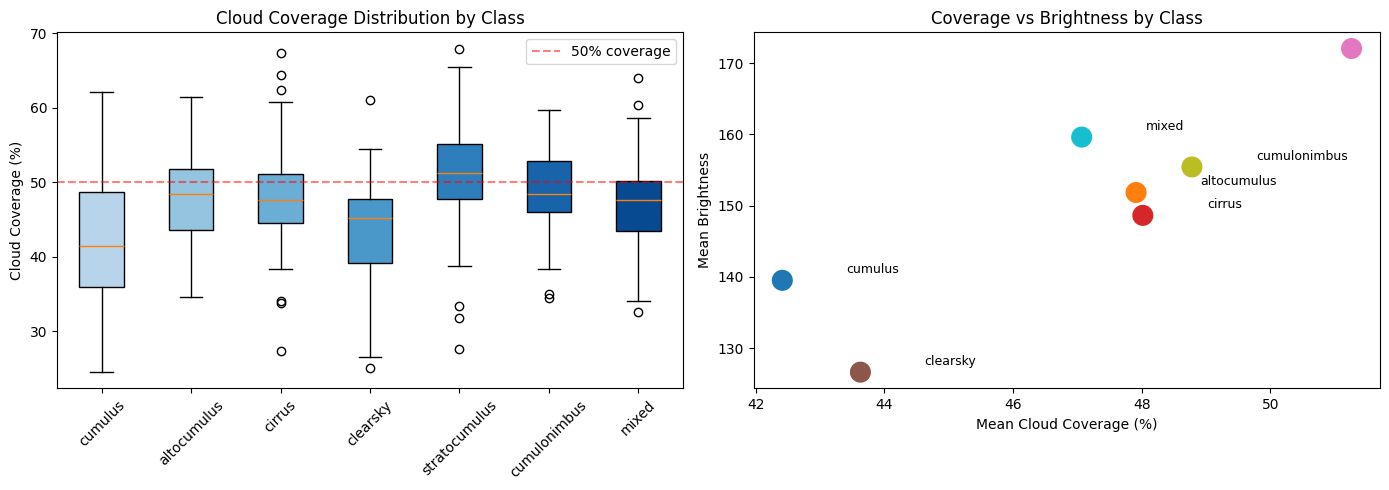


💡 INSIGHT:
   - Clearsky should have LOW coverage (mostly blue sky)
   - Stratocumulus/Cumulonimbus should have HIGH coverage (overcast)
   - This feature can help distinguish clearsky from others!



In [18]:
# =============================================================================
# CELL 18: Cloud Coverage Analysis
# =============================================================================
from PIL import Image
import numpy as np

print("☁️ Analyzing cloud coverage (% of sky covered by clouds)...\n")

# Simple thresholding: bright pixels = clouds, dark pixels = sky
coverage_data = {cls: [] for cls in CLASS_NAMES}

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(100, len(files)))

    for f in sample:
        try:
            with Image.open(os.path.join(cls_path, f)) as img:
                gray = np.array(img.convert('L'))

                # Adaptive threshold: pixels brighter than image mean = cloud
                threshold = gray.mean()
                cloud_pixels = (gray > threshold).sum()
                total_pixels = gray.size
                coverage = cloud_pixels / total_pixels * 100

                coverage_data[cls].append(coverage)
        except:
            pass

# Statistics
print(f"{'Class':<20} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8} {'Interpretation':<25}")
print("-" * 85)

for cls in CLASS_NAMES:
    data = coverage_data[cls]
    short = cls.split('_')[1]
    mean_cov = np.mean(data)

    if mean_cov < 40:
        interp = "Mostly clear sky"
    elif mean_cov < 55:
        interp = "Partial cloud cover"
    else:
        interp = "Heavy cloud cover"

    print(f"{short:<20} {min(data):>7.1f}% {max(data):>7.1f}% {mean_cov:>7.1f}% {np.std(data):>7.1f}% {interp}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
short_names = [c.split('_')[1] for c in CLASS_NAMES]
box_data = [coverage_data[c] for c in CLASS_NAMES]
bp = axes[0].boxplot(box_data, tick_labels=short_names, patch_artist=True)
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(CLASS_NAMES)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel('Cloud Coverage (%)')
axes[0].set_title('Cloud Coverage Distribution by Class')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% coverage')
axes[0].legend()

# Scatter: coverage vs brightness
mean_coverages = [np.mean(coverage_data[c]) for c in CLASS_NAMES]
mean_brightness = [np.mean(brightness_data[c]) for c in CLASS_NAMES]

axes[1].scatter(mean_coverages, mean_brightness, s=200, c=range(len(CLASS_NAMES)), cmap='tab10')
for i, cls in enumerate(CLASS_NAMES):
    axes[1].annotate(cls.split('_')[1], (mean_coverages[i]+1, mean_brightness[i]+1), fontsize=9)
axes[1].set_xlabel('Mean Cloud Coverage (%)')
axes[1].set_ylabel('Mean Brightness')
axes[1].set_title('Coverage vs Brightness by Class')

plt.tight_layout()
plt.show()

print("""
💡 INSIGHT:
   - Clearsky should have LOW coverage (mostly blue sky)
   - Stratocumulus/Cumulonimbus should have HIGH coverage (overcast)
   - This feature can help distinguish clearsky from others!
""")

🔬 Analyzing frequency domain (texture patterns via FFT)...

Class                    Low Freq     Mid Freq    High Freq  Texture Ratio
---------------------------------------------------------------------------
cumulus                   34337.4       3090.6        480.9         0.0137
altocumulus               27800.5       3124.0        468.6         0.0164
cirrus                    15838.7       1021.1        193.8         0.0119
clearsky                   9316.9        516.6        133.0         0.0150
stratocumulus             11457.5        508.6        129.0         0.0111
cumulonimbus              16363.4        991.7        200.7         0.0120
mixed                     28339.8       2762.6        442.7         0.0151


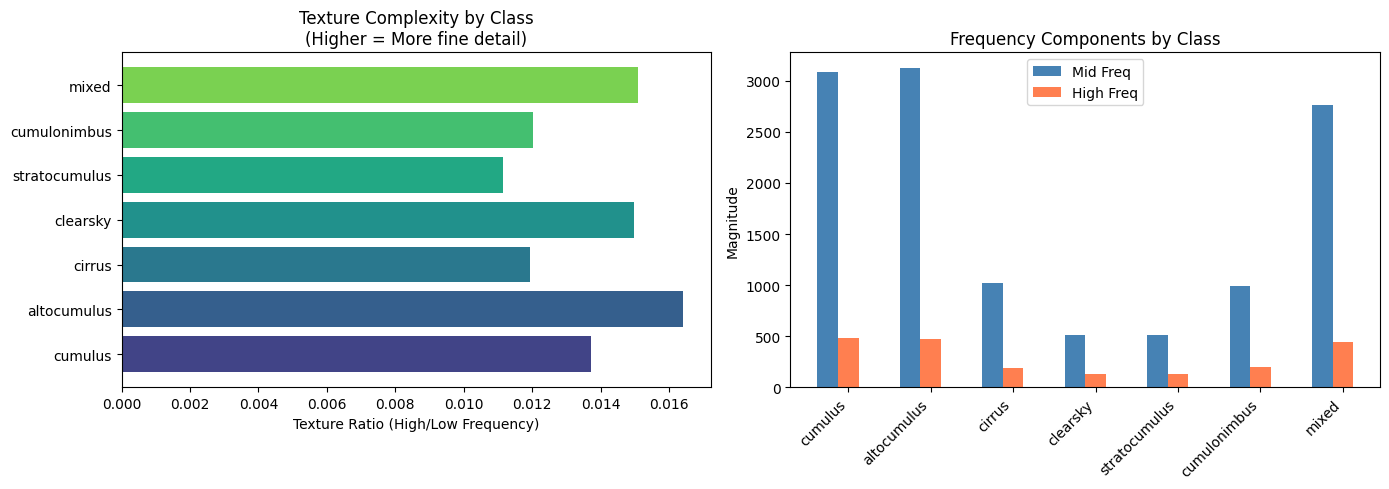


💡 INTERPRETATION:
   High texture ratio = More edges/detail (puffy cumulus, detailed altocumulus)
   Low texture ratio  = Smooth/uniform (clearsky, overcast stratocumulus)



In [19]:
# =============================================================================
# CELL 19: Frequency Domain Analysis (FFT for texture patterns)
# =============================================================================
from PIL import Image
import numpy as np
from scipy import fftpack

print("🔬 Analyzing frequency domain (texture patterns via FFT)...\n")

freq_features = {cls: [] for cls in CLASS_NAMES}

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(80, len(files)))

    for f in sample:
        try:
            with Image.open(os.path.join(cls_path, f)) as img:
                gray = np.array(img.convert('L').resize((256, 256)))

                # 2D FFT
                fft = fftpack.fft2(gray)
                fft_shift = fftpack.fftshift(fft)
                magnitude = np.abs(fft_shift)

                # Analyze frequency bands
                h, w = magnitude.shape
                center_y, center_x = h // 2, w // 2

                # Low frequency (center) - smooth areas
                low_freq = magnitude[center_y-20:center_y+20, center_x-20:center_x+20].mean()

                # Mid frequency - medium detail
                mid_mask = np.zeros_like(magnitude, dtype=bool)
                for i in range(h):
                    for j in range(w):
                        dist = np.sqrt((i - center_y)**2 + (j - center_x)**2)
                        if 20 < dist < 60:
                            mid_mask[i, j] = True
                mid_freq = magnitude[mid_mask].mean()

                # High frequency (edges) - fine detail
                high_mask = np.zeros_like(magnitude, dtype=bool)
                for i in range(h):
                    for j in range(w):
                        dist = np.sqrt((i - center_y)**2 + (j - center_x)**2)
                        if dist > 60:
                            high_mask[i, j] = True
                high_freq = magnitude[high_mask].mean()

                # Ratio: high/low indicates texture complexity
                texture_ratio = high_freq / low_freq if low_freq > 0 else 0

                freq_features[cls].append({
                    'low': low_freq,
                    'mid': mid_freq,
                    'high': high_freq,
                    'ratio': texture_ratio
                })
        except:
            pass

# Summary
print(f"{'Class':<20} {'Low Freq':>12} {'Mid Freq':>12} {'High Freq':>12} {'Texture Ratio':>14}")
print("-" * 75)

for cls in CLASS_NAMES:
    feats = freq_features[cls]
    short = cls.split('_')[1]
    low = np.mean([f['low'] for f in feats])
    mid = np.mean([f['mid'] for f in feats])
    high = np.mean([f['high'] for f in feats])
    ratio = np.mean([f['ratio'] for f in feats])
    print(f"{short:<20} {low:>12.1f} {mid:>12.1f} {high:>12.1f} {ratio:>14.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

short_names = [c.split('_')[1] for c in CLASS_NAMES]
ratios = [np.mean([f['ratio'] for f in freq_features[c]]) for c in CLASS_NAMES]
high_freqs = [np.mean([f['high'] for f in freq_features[c]]) for c in CLASS_NAMES]

# Bar chart of texture ratio
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(CLASS_NAMES)))
axes[0].barh(short_names, ratios, color=colors)
axes[0].set_xlabel('Texture Ratio (High/Low Frequency)')
axes[0].set_title('Texture Complexity by Class\n(Higher = More fine detail)')

# Grouped bar: Low vs Mid vs High
x = np.arange(len(CLASS_NAMES))
width = 0.25
lows = [np.mean([f['low'] for f in freq_features[c]]) / 1000 for c in CLASS_NAMES]  # Scale down
mids = [np.mean([f['mid'] for f in freq_features[c]]) for c in CLASS_NAMES]
highs = [np.mean([f['high'] for f in freq_features[c]]) for c in CLASS_NAMES]

axes[1].bar(x - width, mids, width, label='Mid Freq', color='steelblue')
axes[1].bar(x, highs, width, label='High Freq', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names, rotation=45, ha='right')
axes[1].set_ylabel('Magnitude')
axes[1].set_title('Frequency Components by Class')
axes[1].legend()

plt.tight_layout()
plt.show()

print("""
💡 INTERPRETATION:
   High texture ratio = More edges/detail (puffy cumulus, detailed altocumulus)
   Low texture ratio  = Smooth/uniform (clearsky, overcast stratocumulus)
""")

📐 Analyzing gradient orientations (cloud shapes/edges)...

Class                Grad Mag   Horizontal     Vertical     Diagonal Dominant       
-------------------------------------------------------------------------------------
cumulus                  14.6        0.202        0.296        0.501 Diagonal ↗↘
altocumulus              19.9        0.186        0.311        0.503 Diagonal ↗↘
cirrus                    6.6        0.199        0.314        0.487 Diagonal ↗↘
clearsky                  3.0        0.220        0.344        0.436 Diagonal ↗↘
stratocumulus             2.8        0.206        0.361        0.434 Diagonal ↗↘
cumulonimbus              5.0        0.198        0.325        0.477 Diagonal ↗↘
mixed                    15.5        0.192        0.307        0.502 Diagonal ↗↘


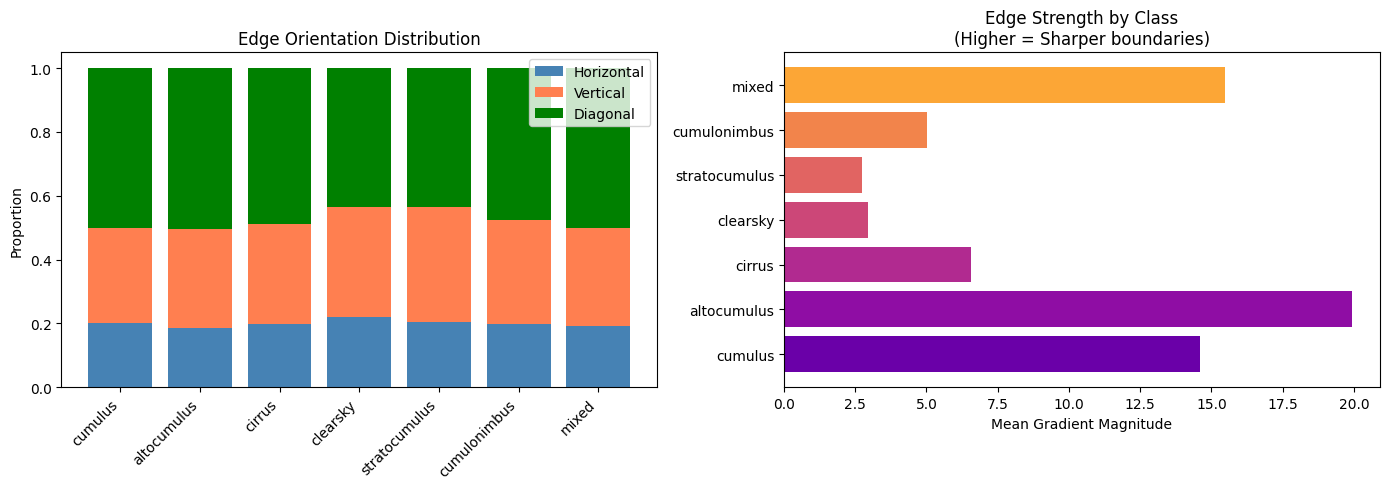


💡 INSIGHT:
   - High gradient magnitude = Sharp cloud boundaries (cumulus)
   - Low gradient magnitude = Soft/blurry edges (cirrus, clearsky)
   - Diagonal dominance = Curved/irregular shapes
   - Horizontal dominance = Layered clouds (stratocumulus)



In [20]:
# =============================================================================
# CELL 20: Gradient Orientation Analysis (Cloud Shapes)
# =============================================================================
from PIL import Image, ImageFilter
import numpy as np

print("📐 Analyzing gradient orientations (cloud shapes/edges)...\n")

gradient_features = {cls: [] for cls in CLASS_NAMES}

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(80, len(files)))

    for f in sample:
        try:
            with Image.open(os.path.join(cls_path, f)) as img:
                gray = np.array(img.convert('L')).astype(float)

                # Sobel gradients
                sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
                sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

                from scipy.ndimage import convolve
                gx = convolve(gray, sobel_x)
                gy = convolve(gray, sobel_y)

                # Gradient magnitude and orientation
                magnitude = np.sqrt(gx**2 + gy**2)
                orientation = np.arctan2(gy, gx) * 180 / np.pi  # -180 to 180

                # Histogram of orientations (weighted by magnitude)
                hist, bins = np.histogram(orientation.flatten(), bins=8, range=(-180, 180),
                                         weights=magnitude.flatten())
                hist = hist / hist.sum()  # Normalize

                # Features
                gradient_features[cls].append({
                    'mag_mean': magnitude.mean(),
                    'mag_std': magnitude.std(),
                    'horizontal': hist[0] + hist[4],  # 0° and 180° (horizontal edges)
                    'vertical': hist[2] + hist[6],    # 90° and -90° (vertical edges)
                    'diagonal': hist[1] + hist[3] + hist[5] + hist[7],  # diagonal edges
                    'hist': hist
                })
        except:
            pass

# Summary
print(f"{'Class':<18} {'Grad Mag':>10} {'Horizontal':>12} {'Vertical':>12} {'Diagonal':>12} {'Dominant':<15}")
print("-" * 85)

for cls in CLASS_NAMES:
    feats = gradient_features[cls]
    short = cls.split('_')[1]
    mag = np.mean([f['mag_mean'] for f in feats])
    horiz = np.mean([f['horizontal'] for f in feats])
    vert = np.mean([f['vertical'] for f in feats])
    diag = np.mean([f['diagonal'] for f in feats])

    # Dominant direction
    if horiz > vert and horiz > diag:
        dominant = "Horizontal →"
    elif vert > horiz and vert > diag:
        dominant = "Vertical ↕"
    else:
        dominant = "Diagonal ↗↘"

    print(f"{short:<18} {mag:>10.1f} {horiz:>12.3f} {vert:>12.3f} {diag:>12.3f} {dominant}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: orientation distribution
short_names = [c.split('_')[1] for c in CLASS_NAMES]
horiz_vals = [np.mean([f['horizontal'] for f in gradient_features[c]]) for c in CLASS_NAMES]
vert_vals = [np.mean([f['vertical'] for f in gradient_features[c]]) for c in CLASS_NAMES]
diag_vals = [np.mean([f['diagonal'] for f in gradient_features[c]]) for c in CLASS_NAMES]

x = np.arange(len(CLASS_NAMES))
axes[0].bar(x, horiz_vals, label='Horizontal', color='steelblue')
axes[0].bar(x, vert_vals, bottom=horiz_vals, label='Vertical', color='coral')
axes[0].bar(x, diag_vals, bottom=np.array(horiz_vals)+np.array(vert_vals), label='Diagonal', color='green')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, rotation=45, ha='right')
axes[0].set_ylabel('Proportion')
axes[0].set_title('Edge Orientation Distribution')
axes[0].legend()

# Gradient magnitude comparison
mags = [np.mean([f['mag_mean'] for f in gradient_features[c]]) for c in CLASS_NAMES]
axes[1].barh(short_names, mags, color=plt.cm.plasma(np.linspace(0.2, 0.8, len(CLASS_NAMES))))
axes[1].set_xlabel('Mean Gradient Magnitude')
axes[1].set_title('Edge Strength by Class\n(Higher = Sharper boundaries)')

plt.tight_layout()
plt.show()

print("""
💡 INSIGHT:
   - High gradient magnitude = Sharp cloud boundaries (cumulus)
   - Low gradient magnitude = Soft/blurry edges (cirrus, clearsky)
   - Diagonal dominance = Curved/irregular shapes
   - Horizontal dominance = Layered clouds (stratocumulus)
""")

🎨 Analyzing color histogram signatures per class...



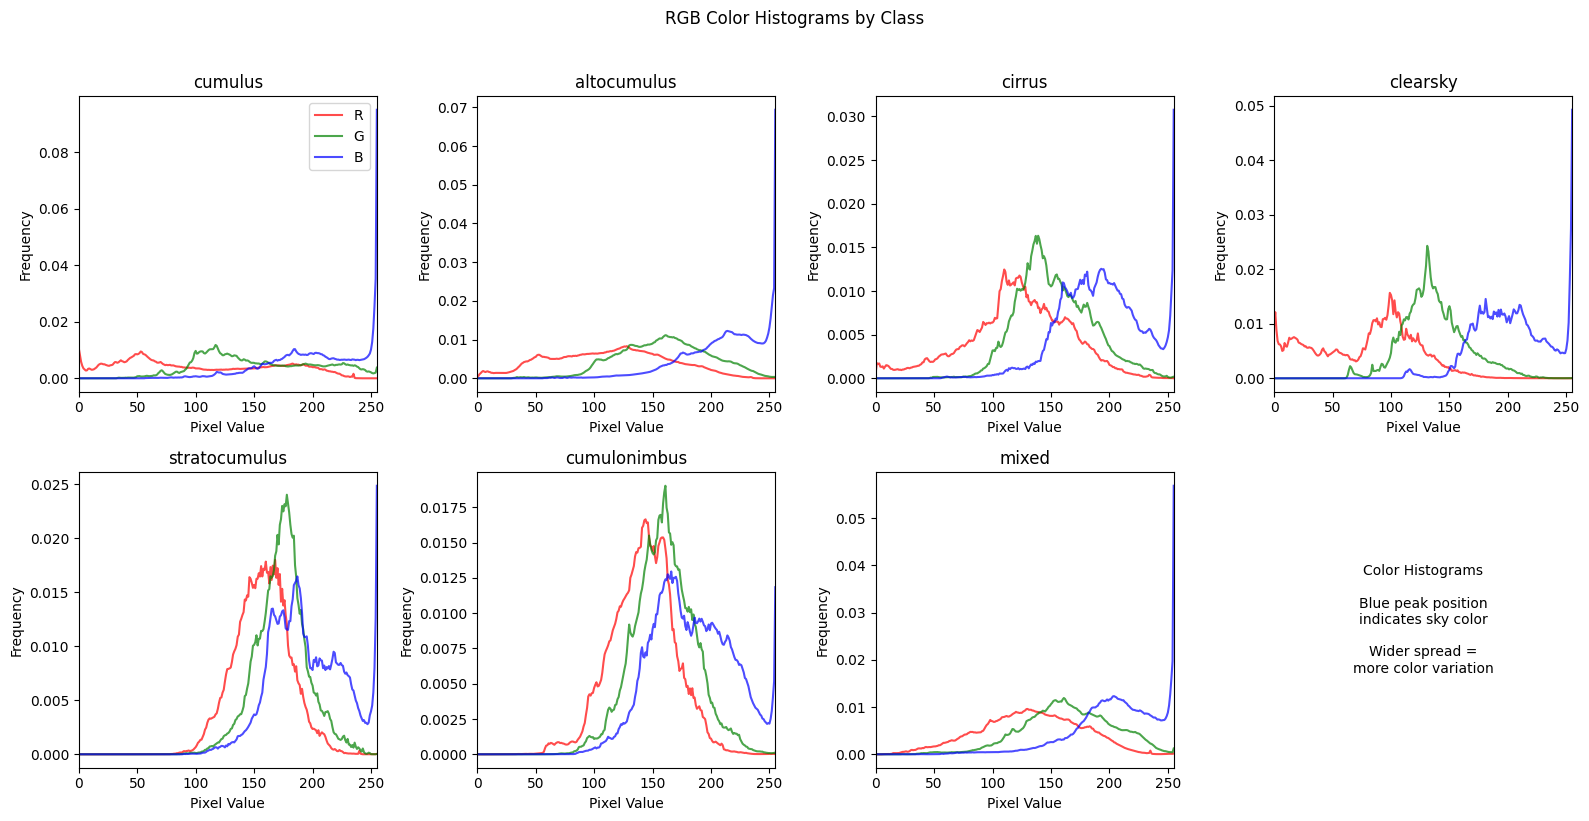

Class                R Peak   G Peak   B Peak   B Spread Signature           
--------------------------------------------------------------------------------
cumulus                   0      117      255       40.3 Very bright sky
altocumulus             128      161      255       34.4 Very bright sky
cirrus                  110      139      255       34.2 Very bright sky
clearsky                 99      131      255       30.8 Very bright sky
stratocumulus           168      178      255       30.7 Very bright sky
cumulonimbus            144      161      166       33.5 Standard blue sky
mixed                   130      161      255       36.1 Very bright sky

💡 INSIGHT:
   - Blue peak position indicates typical sky brightness
   - Higher B peak = brighter/whiter sky (more cloud cover)
   - Narrow spread = consistent color; Wide spread = varied conditions



In [21]:
# =============================================================================
# CELL 21: Color Histogram Signatures
# =============================================================================
from PIL import Image
import numpy as np

print("🎨 Analyzing color histogram signatures per class...\n")

color_histograms = {cls: {'R': [], 'G': [], 'B': []} for cls in CLASS_NAMES}

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(80, len(files)))

    r_hist_sum = np.zeros(256)
    g_hist_sum = np.zeros(256)
    b_hist_sum = np.zeros(256)

    for f in sample:
        try:
            with Image.open(os.path.join(cls_path, f)) as img:
                arr = np.array(img.convert('RGB'))

                r_hist, _ = np.histogram(arr[:,:,0].flatten(), bins=256, range=(0, 256))
                g_hist, _ = np.histogram(arr[:,:,1].flatten(), bins=256, range=(0, 256))
                b_hist, _ = np.histogram(arr[:,:,2].flatten(), bins=256, range=(0, 256))

                r_hist_sum += r_hist / r_hist.sum()
                g_hist_sum += g_hist / g_hist.sum()
                b_hist_sum += b_hist / b_hist.sum()
        except:
            pass

    # Normalize
    n = len(sample)
    color_histograms[cls]['R'] = r_hist_sum / n
    color_histograms[cls]['G'] = g_hist_sum / n
    color_histograms[cls]['B'] = b_hist_sum / n

# Visualize histograms for each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, cls in enumerate(CLASS_NAMES):
    ax = axes[idx]
    ax.plot(color_histograms[cls]['R'], color='red', alpha=0.7, label='R')
    ax.plot(color_histograms[cls]['G'], color='green', alpha=0.7, label='G')
    ax.plot(color_histograms[cls]['B'], color='blue', alpha=0.7, label='B')
    ax.set_title(cls.split('_')[1])
    ax.set_xlim(0, 255)
    ax.set_xlabel('Pixel Value')
    ax.set_ylabel('Frequency')
    if idx == 0:
        ax.legend()

# Hide last empty subplot
axes[7].axis('off')
axes[7].text(0.5, 0.5, 'Color Histograms\n\nBlue peak position\nindicates sky color\n\nWider spread =\nmore color variation',
             ha='center', va='center', fontsize=10, transform=axes[7].transAxes)

plt.suptitle('RGB Color Histograms by Class', y=1.02)
plt.tight_layout()
plt.show()

# Quantify histogram characteristics
print(f"{'Class':<18} {'R Peak':>8} {'G Peak':>8} {'B Peak':>8} {'B Spread':>10} {'Signature':<20}")
print("-" * 80)

for cls in CLASS_NAMES:
    short = cls.split('_')[1]
    r_peak = np.argmax(color_histograms[cls]['R'])
    g_peak = np.argmax(color_histograms[cls]['G'])
    b_peak = np.argmax(color_histograms[cls]['B'])

    # Blue spread (std of histogram)
    b_vals = np.arange(256)
    b_hist = color_histograms[cls]['B']
    b_mean = np.sum(b_vals * b_hist)
    b_spread = np.sqrt(np.sum(((b_vals - b_mean) ** 2) * b_hist))

    # Signature interpretation
    if b_peak > 220:
        sig = "Very bright sky"
    elif b_peak > 180:
        sig = "Bright blue sky"
    elif r_peak > g_peak:
        sig = "Warm tones (sunset?)"
    else:
        sig = "Standard blue sky"

    print(f"{short:<18} {r_peak:>8} {g_peak:>8} {b_peak:>8} {b_spread:>10.1f} {sig}")

print("""
💡 INSIGHT:
   - Blue peak position indicates typical sky brightness
   - Higher B peak = brighter/whiter sky (more cloud cover)
   - Narrow spread = consistent color; Wide spread = varied conditions
""")

🔄 Analyzing image symmetry and uniformity...

Class                H-Symmetry   V-Symmetry   Uniformity    Local Var
----------------------------------------------------------------------
cumulus                   0.850        0.819        0.842         39.5
altocumulus               0.889        0.874        0.885         21.3
cirrus                    0.913        0.898        0.885         19.0
clearsky                  0.954        0.943        0.920         10.9
stratocumulus             0.954        0.946        0.929         10.2
cumulonimbus              0.931        0.906        0.903         17.1
mixed                     0.873        0.859        0.880         26.5


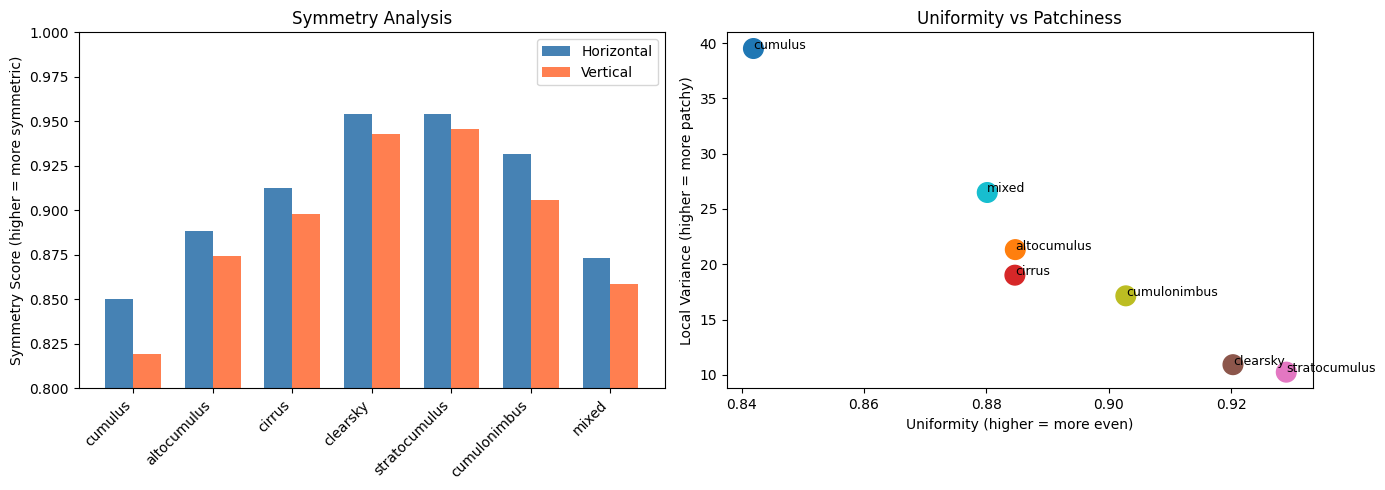


💡 INSIGHT:
   - High symmetry + high uniformity = Overcast/clearsky (even coverage)
   - Low symmetry + high local variance = Scattered clouds (cumulus, altocumulus)
   - This helps distinguish scattered vs layered cloud types!



In [22]:
# =============================================================================
# CELL 22: Symmetry & Uniformity Analysis
# =============================================================================
from PIL import Image
import numpy as np

print("🔄 Analyzing image symmetry and uniformity...\n")

symmetry_features = {cls: [] for cls in CLASS_NAMES}

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(80, len(files)))

    for f in sample:
        try:
            with Image.open(os.path.join(cls_path, f)) as img:
                gray = np.array(img.convert('L')).astype(float)
                h, w = gray.shape

                # Horizontal symmetry (left vs right)
                left = gray[:, :w//2]
                right = gray[:, w//2:][:, ::-1]  # Flip right side
                h_sym = 1 - np.abs(left - right).mean() / 255

                # Vertical symmetry (top vs bottom)
                top = gray[:h//2, :]
                bottom = gray[h//2:, :][::-1, :]  # Flip bottom
                v_sym = 1 - np.abs(top - bottom).mean() / 255

                # Quadrant uniformity (how similar are the 4 quadrants?)
                q1 = gray[:h//2, :w//2].mean()
                q2 = gray[:h//2, w//2:].mean()
                q3 = gray[h//2:, :w//2].mean()
                q4 = gray[h//2:, w//2:].mean()
                quadrant_std = np.std([q1, q2, q3, q4])
                uniformity = 1 - quadrant_std / 128  # Normalize

                # Local variance (patchwise consistency)
                patch_size = 64
                patch_means = []
                for i in range(0, h - patch_size, patch_size):
                    for j in range(0, w - patch_size, patch_size):
                        patch_means.append(gray[i:i+patch_size, j:j+patch_size].mean())
                local_var = np.std(patch_means)

                symmetry_features[cls].append({
                    'h_sym': h_sym,
                    'v_sym': v_sym,
                    'uniformity': uniformity,
                    'local_var': local_var
                })
        except:
            pass

# Summary
print(f"{'Class':<18} {'H-Symmetry':>12} {'V-Symmetry':>12} {'Uniformity':>12} {'Local Var':>12}")
print("-" * 70)

for cls in CLASS_NAMES:
    feats = symmetry_features[cls]
    short = cls.split('_')[1]
    h_sym = np.mean([f['h_sym'] for f in feats])
    v_sym = np.mean([f['v_sym'] for f in feats])
    unif = np.mean([f['uniformity'] for f in feats])
    local_var = np.mean([f['local_var'] for f in feats])
    print(f"{short:<18} {h_sym:>12.3f} {v_sym:>12.3f} {unif:>12.3f} {local_var:>12.1f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

short_names = [c.split('_')[1] for c in CLASS_NAMES]

# Symmetry comparison
h_syms = [np.mean([f['h_sym'] for f in symmetry_features[c]]) for c in CLASS_NAMES]
v_syms = [np.mean([f['v_sym'] for f in symmetry_features[c]]) for c in CLASS_NAMES]

x = np.arange(len(CLASS_NAMES))
width = 0.35
axes[0].bar(x - width/2, h_syms, width, label='Horizontal', color='steelblue')
axes[0].bar(x + width/2, v_syms, width, label='Vertical', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, rotation=45, ha='right')
axes[0].set_ylabel('Symmetry Score (higher = more symmetric)')
axes[0].set_title('Symmetry Analysis')
axes[0].legend()
axes[0].set_ylim(0.8, 1.0)

# Uniformity vs Local Variance
uniformities = [np.mean([f['uniformity'] for f in symmetry_features[c]]) for c in CLASS_NAMES]
local_vars = [np.mean([f['local_var'] for f in symmetry_features[c]]) for c in CLASS_NAMES]

axes[1].scatter(uniformities, local_vars, s=200, c=range(len(CLASS_NAMES)), cmap='tab10')
for i, name in enumerate(short_names):
    axes[1].annotate(name, (uniformities[i], local_vars[i]), fontsize=9)
axes[1].set_xlabel('Uniformity (higher = more even)')
axes[1].set_ylabel('Local Variance (higher = more patchy)')
axes[1].set_title('Uniformity vs Patchiness')

plt.tight_layout()
plt.show()

print("""
💡 INSIGHT:
   - High symmetry + high uniformity = Overcast/clearsky (even coverage)
   - Low symmetry + high local variance = Scattered clouds (cumulus, altocumulus)
   - This helps distinguish scattered vs layered cloud types!
""")

In [23]:
# =============================================================================
# CELL 23: PRACTICAL SUMMARY - WHAT YOU NEED FOR TRAINING
# =============================================================================

print("=" * 75)
print("🎯 PRACTICAL SUMMARY: WHAT ACTUALLY MATTERS")
print("=" * 75)

practical = """
┌─────────────────────────────────────────────────────────────────────────────┐
│  ✅ COPY-PASTE FOR TRAINING                                                 │
└─────────────────────────────────────────────────────────────────────────────┘

1. NORMALIZATION:
   mean = [0.4674, 0.6149, 0.7809]
   std  = [0.2027, 0.1410, 0.1403]

2. CLASS WEIGHTS (inverse frequency):
   weights = {
       '1_cumulus':       1.29,
       '2_altocumulus':   1.38,
       '3_cirrus':        0.87,
       '4_clearsky':      0.47,
       '5_stratocumulus': 0.54,
       '6_cumulonimbus':  0.33,
       '7_mixed':         2.87
   }

3. DATA PATHS:
   TRAIN_PATH = "/path/to/GCD/train"
   TEST_PATH  = "/path/to/GCD/test"

4. CLEAN TEST SET (remove 156 leaked files):
   See: leaked_test_files.txt

┌─────────────────────────────────────────────────────────────────────────────┐
│  ⚠️ ISSUES TO REMEMBER                                                      │
└─────────────────────────────────────────────────────────────────────────────┘

1. DATA LEAKAGE: 156 images in both train & test (mostly clearsky)
   → Remove from test OR report adjusted accuracy

2. CLASS IMBALANCE: 8.63x (cumulonimbus vs mixed)
   → Use weighted CrossEntropyLoss

3. HARD PAIRS (expect confusion here):
   → Cumulonimbus ↔ Stratocumulus
   → Altocumulus ↔ Clearsky
   → Cirrus ↔ Clearsky

┌─────────────────────────────────────────────────────────────────────────────┐
│  🚀 RECOMMENDED TRAINING SETUP                                              │
└─────────────────────────────────────────────────────────────────────────────┘

Model:       EfficientNet-B2 or ResNet-50 (pretrained ImageNet)
Input size:  384×384 or 224×224
Batch size:  32-64
Optimizer:   AdamW, lr=1e-4
Scheduler:   CosineAnnealing or ReduceLROnPlateau
Epochs:      30-50 with early stopping
Loss:        CrossEntropyLoss with class weights

Expected accuracy: 85-92%
"""
print(practical)

# Save practical summary
with open('/content/TJNU_GCD_practical_summary.txt', 'w') as f:
    f.write(practical)

print("\n💾 Saved: /content/TJNU_GCD_practical_summary.txt")
print("\n" + "=" * 75)
print("✅ ANALYSIS COMPLETE - Ready for training!")
print("=" * 75)

🎯 PRACTICAL SUMMARY: WHAT ACTUALLY MATTERS

┌─────────────────────────────────────────────────────────────────────────────┐
│  ✅ COPY-PASTE FOR TRAINING                                                 │
└─────────────────────────────────────────────────────────────────────────────┘

1. NORMALIZATION:
   mean = [0.4674, 0.6149, 0.7809]
   std  = [0.2027, 0.1410, 0.1403]

2. CLASS WEIGHTS (inverse frequency):
   weights = {
       '1_cumulus':       1.29,
       '2_altocumulus':   1.38,
       '3_cirrus':        0.87,
       '4_clearsky':      0.47,
       '5_stratocumulus': 0.54,
       '6_cumulonimbus':  0.33,
       '7_mixed':         2.87
   }

3. DATA PATHS:
   TRAIN_PATH = "/path/to/GCD/train"
   TEST_PATH  = "/path/to/GCD/test"
   
4. CLEAN TEST SET (remove 156 leaked files):
   See: leaked_test_files.txt

┌─────────────────────────────────────────────────────────────────────────────┐
│  ⚠️ ISSUES TO REMEMBER                                                      │
└────────────────

In [25]:
# =============================================================================
# CELL 24: Training Config - HIGH-END INFRASTRUCTURE
# =============================================================================

print("=" * 75)
print("🖥️ TRAINING CONFIG: POWERFUL INFRASTRUCTURE")
print("=" * 75)



high_end_config = """
┌─────────────────────────────────────────────────────────────────────────────┐
│  🚀 RECOMMENDED HIGH-END CONFIG                                             │
└─────────────────────────────────────────────────────────────────────────────┘

# === MODEL OPTIONS (pick one) ===

OPTION A: Best accuracy (slower)
    model = "convnext_large"  or "efficientnet_b7"
    input_size = 512  # Use full resolution!
    batch_size = 64-128

OPTION B: Good balance (recommended)
    model = "convnext_base" or "efficientnet_b5"
    input_size = 448
    batch_size = 128

OPTION C: Fast iteration
    model = "efficientnet_b3" or "resnet101"
    input_size = 384
    batch_size = 256

# === FULL CONFIG ===

config = {
    # Data
    "input_size": 448,          # Higher = more detail from 512×512 originals
    "batch_size": 128,          # Larger = more stable gradients
    "num_workers": 8,           # Parallel data loading

    # Model
    "model": "convnext_base",   # or efficientnet_b5, vit_base_patch16
    "pretrained": True,         # ImageNet weights
    "num_classes": 7,

    # Training
    "epochs": 100,
    "early_stopping_patience": 15,
    "optimizer": "AdamW",
    "lr": 1e-4,
    "weight_decay": 0.05,
    "scheduler": "CosineAnnealingWarmRestarts",
    "warmup_epochs": 5,

    # Mixed precision (faster + less memory)
    "use_amp": True,            # Automatic Mixed Precision

    # Augmentation (heavier for more data)
    "augmentation": "strong",   # RandAugment, CutMix, MixUp

    # Class imbalance
    "class_weights": [1.29, 1.38, 0.87, 0.47, 0.54, 0.33, 2.87],

    # Regularization
    "dropout": 0.3,
    "label_smoothing": 0.1,     # Helps with ambiguous classes
    "stochastic_depth": 0.2,    # For ConvNeXt/EfficientNet
}

┌─────────────────────────────────────────────────────────────────────────────┐
│  📊 EXPECTED RESULTS BY CONFIG                                              │
├─────────────────────────┬───────────────────────────────────────────────────┤
│  Config                 │  Expected Accuracy (clean test set)               │
├─────────────────────────┼───────────────────────────────────────────────────┤
│  ResNet-50, 224px       │  82-86%                                           │
│  EfficientNet-B3, 384px │  86-89%                                           │
│  EfficientNet-B5, 448px │  88-91%                                           │
│  ConvNeXt-Base, 448px   │  89-92%                                           │
│  ConvNeXt-Large, 512px  │  90-93%                                           │
│  Ensemble (3 models)    │  92-95%                                           │
└─────────────────────────┴───────────────────────────────────────────────────┘
"""
print(high_end_config)

pytorch_code = '''
┌─────────────────────────────────────────────────────────────────────────────┐
│  📝 PYTORCH CODE SNIPPETS                                                   │
└─────────────────────────────────────────────────────────────────────────────┘

# === TRANSFORMS (High-End) ===

import torchvision.transforms as T
from timm.data.auto_augment import rand_augment_transform

train_transform = T.Compose([
    T.Resize((512, 512)),
    T.RandomResizedCrop(448, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.15, hue=0.02),
    T.RandAugment(num_ops=2, magnitude=9),  # Optional: strong augmentation
    T.ToTensor(),
    T.Normalize(mean=[0.4674, 0.6149, 0.7809],
                std=[0.2027, 0.1410, 0.1403]),
    T.RandomErasing(p=0.25),  # Cutout-like regularization
])

val_transform = T.Compose([
    T.Resize((448, 448)),
    T.ToTensor(),
    T.Normalize(mean=[0.4674, 0.6149, 0.7809],
                std=[0.2027, 0.1410, 0.1403]),
])


# === MODEL WITH TIMM ===

import timm

model = timm.create_model(
    'convnext_base',           # or efficientnet_b5, vit_base_patch16_384
    pretrained=True,
    num_classes=7,
    drop_path_rate=0.2,        # Stochastic depth
)


# === CLASS WEIGHTS ===

import torch
import torch.nn as nn

class_weights = torch.tensor([1.29, 1.38, 0.87, 0.47, 0.54, 0.33, 2.87])
criterion = nn.CrossEntropyLoss(
    weight=class_weights.cuda(),
    label_smoothing=0.1
)


# === MIXED PRECISION TRAINING ===

from torch.cuda.amp import GradScaler, autocast

scaler = GradScaler()

for batch in dataloader:
    optimizer.zero_grad()

    with autocast():  # FP16 forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()


# === TEST-TIME AUGMENTATION (TTA) ===

def predict_with_tta(model, image):
    """5-crop TTA + horizontal flip = 10 predictions averaged"""
    transforms_tta = [
        lambda x: x,                              # Original
        lambda x: T.functional.hflip(x),          # H-flip
        lambda x: T.functional.five_crop(x, 384), # 5 crops
    ]

    predictions = []
    for t in transforms_tta:
        aug_img = t(image)
        pred = model(aug_img)
        predictions.append(pred)

    return torch.stack(predictions).mean(dim=0)
'''
print(pytorch_code)

# Save config
full_config = high_end_config + pytorch_code

with open('/content/TJNU_GCD_highend_config.txt', 'w') as f:
    f.write(full_config)

print("\n💾 Saved: /content/TJNU_GCD_highend_config.txt")

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  💡 KEY DIFFERENCES WITH POWERFUL INFRA                                     │
└─────────────────────────────────────────────────────────────────────────────┘

1. USE FULL 512×512 RESOLUTION (or 448) - you paid for those pixels!

2. LARGER MODELS - ConvNeXt-Large, EfficientNet-B7, ViT-Large
   → More parameters = better texture learning

3. BIGGER BATCHES - 128-256
   → More stable gradients, better convergence

4. HEAVIER AUGMENTATION - RandAugment, CutMix, MixUp
   → Prevents overfitting with 10K images

5. MIXED PRECISION (AMP) - Free 2x speedup

6. ENSEMBLE MODELS - Train 3-5 different architectures, average predictions
   → +2-3% accuracy boost

7. TEST-TIME AUGMENTATION - Multiple crops/flips at inference
   → +1-2% accuracy boost
""")

🖥️ TRAINING CONFIG: POWERFUL INFRASTRUCTURE

┌─────────────────────────────────────────────────────────────────────────────┐
│  🚀 RECOMMENDED HIGH-END CONFIG                                             │
└─────────────────────────────────────────────────────────────────────────────┘

# === MODEL OPTIONS (pick one) ===

OPTION A: Best accuracy (slower)
    model = "convnext_large"  or "efficientnet_b7"
    input_size = 512  # Use full resolution!
    batch_size = 64-128

OPTION B: Good balance (recommended)
    model = "convnext_base" or "efficientnet_b5"
    input_size = 448
    batch_size = 128

OPTION C: Fast iteration
    model = "efficientnet_b3" or "resnet101"
    input_size = 384
    batch_size = 256

# === FULL CONFIG ===

config = {
    # Data
    "input_size": 448,          # Higher = more detail from 512×512 originals
    "batch_size": 128,          # Larger = more stable gradients
    "num_workers": 8,           # Parallel data loading
    
    # Model
    "model": "convnext